Experiments with lstm

In [ ]:
from pathlib import Path

notebook_path = Path().resolve()

# Step 2: Go up 2 levels
PROJECT_ROOT = notebook_path.parents[1]  # use [1] instead of [2] if you're already 1 level down

print(PROJECT_ROOT)
TMP_DIR = PROJECT_ROOT / 'tmp'
DATA_DIR = PROJECT_ROOT / 'data'
LSTM_MODELS_DIR = PROJECT_ROOT /'src'/ 'autoregression' /'models' / 'saved'
ML_FLOW_DIR=PROJECT_ROOT /'mlruns'
from src.autoregression.utils_ar import prepare_direct_lstm_data,prepare_recursive_lstm_data, run_direct_lstm_experiment, run_recursive_lstm_experiment
from src.evaluation import evalresu as er
import mlflow
mlflow.set_tracking_uri(ML_FLOW_DIR)



C:\SVN\Python projects\Thesis Project


In [9]:
import joblib
n_past_values=100
n_future_values=20
input_shape=(n_past_values,1)


Data preparation

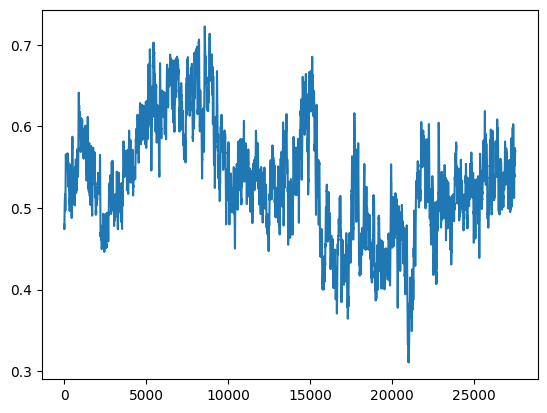

In [10]:
import matplotlib.pyplot as plt
data = joblib.load(TMP_DIR / 'output1_smoothed_RTS.pkl')
plt.plot(data)

In [11]:

X_train_dir, y_train_dir,X_val_dir,y_val_dir,X_test_dir,y_test_dir = prepare_direct_lstm_data(data,100,20)
#X_train_dir_raw, y_train_dir_raw,X_val_dir_raw,y_val_dir_raw,X_test_dir_raw,y_test_dir_raw = prepare_direct_lstm_data(data_2,n_past_values,n_future_values)

X_train_rec, y_train_rec,X_val_rec,y_val_rec,X_test_rec,y_test_rec = prepare_recursive_lstm_data(data,n_past_values)

In [12]:
def set_latex_plot_style(scale=1.0, rel_fontsize_scale=1.0,square=False):
    """
    Set matplotlib rcParams for plots intended for LaTeX documents.

    Args:
        scale (float): How much width to take compared to \textwidth. 1.0 = full width, 0.5 = half width.
        rel_fontsize_scale (float): Extra scaling for font size to counter LaTeX shrinking (typically 1/scale).
    """
    import matplotlib as mpl

    # LaTeX typical \textwidth in points for A4 11pt doc
    text_width_pt = 426.79135
    inches_per_pt = 1.0 / 72.27
    golden_ratio = (5**0.5 - 1) / 2
    if square:
        golden_ratio = 0.8
   

    fig_width = text_width_pt * inches_per_pt * scale
    fig_height = fig_width * golden_ratio

    base_font_size = 11 /rel_fontsize_scale  # Boost font size relative to shrink factor

    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Computer Modern Roman"],
        "font.size": base_font_size,
        "axes.labelsize": base_font_size,
        "axes.titlesize": base_font_size * 1.1,
        "xtick.labelsize": base_font_size,
        "ytick.labelsize": base_font_size,
        "legend.fontsize": base_font_size ,
        "figure.figsize": (fig_width, fig_height),
        'legend.labelspacing':0.2,       # vertical space between labels
        'legend.handlelength': 1.0,        # length of legend handles
        'legend.handletextpad': 0.3 ,      # space between handle and text
        'legend.borderaxespad': 0.3,       # padding between axes and legend
        'legend.borderpad': 0.2,           # padding inside legend box
        'legend.columnspacing': 0.5,       # space between columns
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "text.usetex": False,
        "axes.grid": True,
        "grid.alpha": 0.5,
        "grid.linestyle": ":",
        "xtick.direction": "in",
        "ytick.direction": "in",
    })



In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
set_latex_plot_style(1.9,0.4,False)

# Example dummy data – replace with your actual arrays
# y_train_dir, y_val_dir, y_test_dir = ...

# -------------------- KDE Distribution Plot --------------------
#plt.figure(figsize=(6, 4))
sns.kdeplot(y_train_dir[:,0].flatten(), label='Train', fill=True, alpha=0.5)
sns.kdeplot(y_val_dir[:,0].flatten(), label='Validation', fill=True, alpha=0.5)
sns.kdeplot(y_test_dir[:,0].flatten(), label='Test', fill=True, alpha=0.5)

plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("trainvaltest distr.pdf", bbox_inches='tight')
plt.close()

# -------------------- Time Series Plot --------------------
#plt.figure(figsize=(6, 4))

# Generate x-axis for each set
x_train = range(len(y_train_dir[:,0].flatten()))
x_val = range(len(y_train_dir[:,0].flatten()),len(y_val_dir[:,0].flatten()) + len(y_train_dir[:,0].flatten()))
x_test = range(len(y_val_dir[:,0].flatten()) + len(y_train_dir[:,0].flatten()),len(y_test_dir[:,0].flatten()) + len(y_train_dir[:,0].flatten()) + len(y_val_dir[:,0].flatten()))

plt.plot(x_train, y_train_dir[:,0].flatten(), label='Train', color='blue')
plt.plot(x_val, y_val_dir[:,0].flatten(), label='Validation', color='orange')
plt.plot(x_test, y_test_dir[:,0].flatten(), label='Test', color='green')

plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig("non stationary df.pdf", bbox_inches='tight')
plt.close()


Direct Multioutput Model

In [ ]:
from src.autoregression.models.DirMultiLSTM import build_direct_lstm_model_simple, build_advanced_direct_lstm,build_direct_model_avg

Direct Simple 128 units

(100, 1)


Model: "Direct_LSTM_Model_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,140 (270.08 KB)

 Trainable params: 69,140 (270.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0240 - mae: 0.0743 - mse: 0.0240
Epoch 1: val_loss improved from inf to 0.00081, saving model to models/saved/Direct_LSTM_Model_simple_new_data.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 52s 97ms/step - loss: 0.0240 - mae: 0.0742 - mse: 0.0240 - val_loss: 8.1452e-04 - val_mae: 0.0227 - val_mse: 8.1452e-04 - learning_rate: 0.0010
Epoch 2/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 5.4474e-04 - mae: 0.0179 - mse: 5.4474e-04
Epoch 2: val_loss improved from 0.00081 to 0.00053, saving model to models/saved/Direct_LSTM_Model_simple_new_data.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 49s 95ms/step - loss: 5.4473e-04 - mae: 0.0179 - mse: 5.4473e-04 - val_loss: 5.2849e-04 - val_mae: 0.0179 - val_mse: 5.2849e-04 - learning_rate: 0.0010
Epoch 3/100
516/517 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 5.0803e-04 - mae: 0.0173 - mse: 5.0803e-04
Epoch 3: val_loss improved from 0.00053 to 0.00047, saving model to models/saved/Direct_LSTM_Model_si

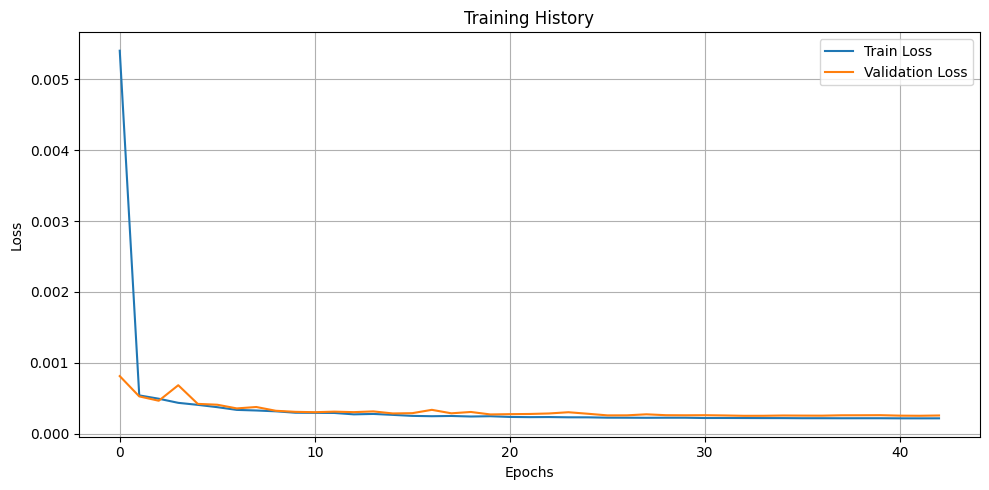

169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step
  Metric       Value
0    MSE    0.000557
1    MAE    0.018907
2   RMSE    0.023602
3     R2    0.567913
4   MAPE    3.637650
5  SMAPE    3.641376
6    SAE  101.853971


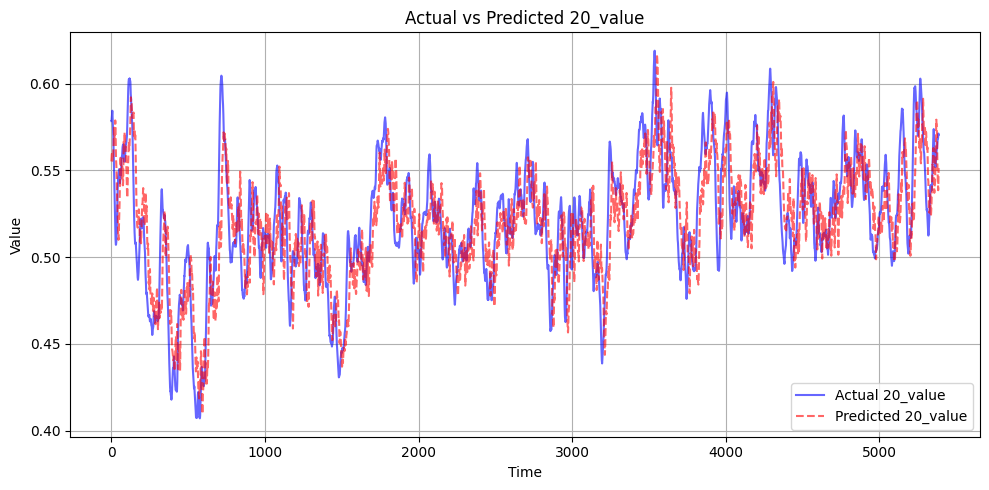

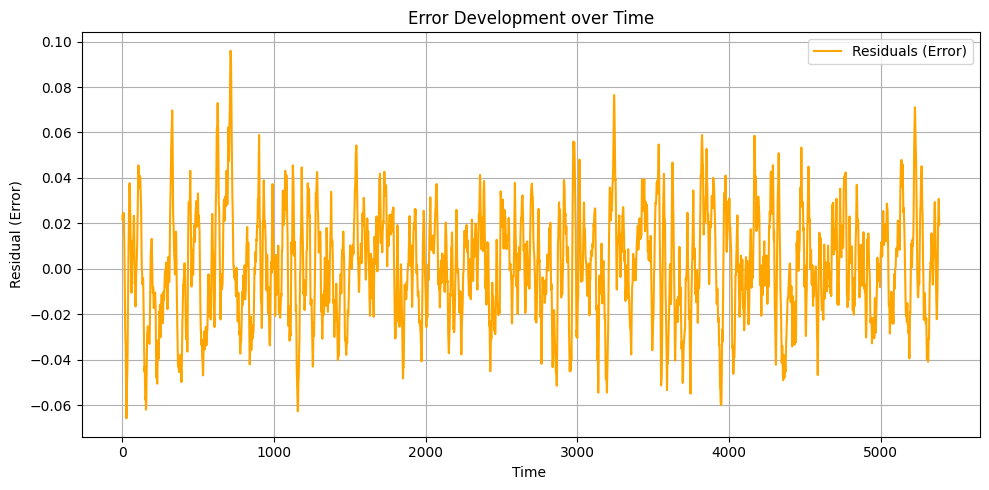

  Metric      Value
0    MSE   0.000159
1    MAE   0.010651
2   RMSE   0.012593
3     R2 -12.390397
4   MAPE   1.853672
5  SMAPE   1.877938
6    SAE   0.213027


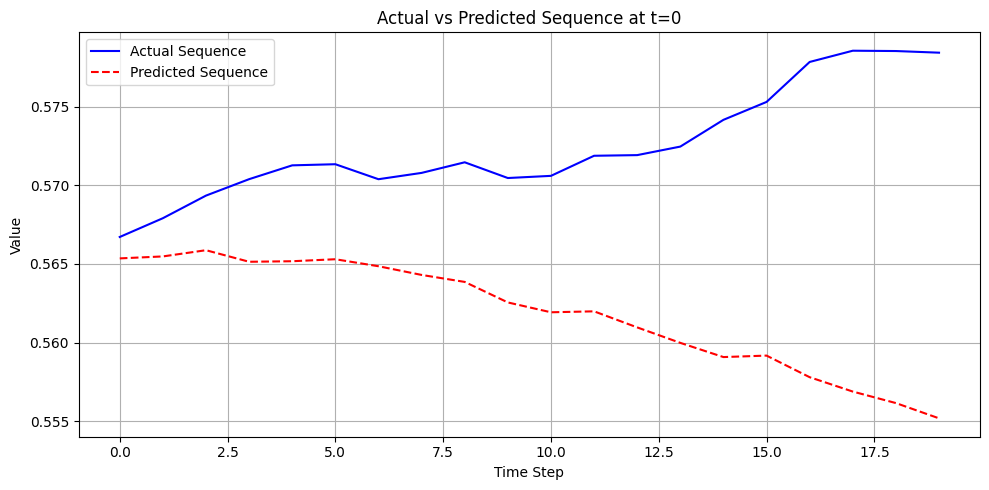

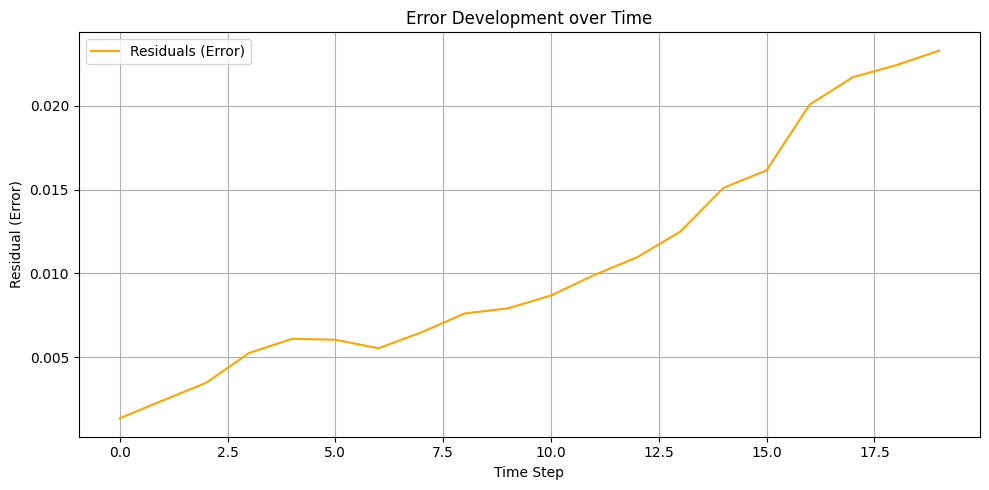

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


Successfully registered model 'Direct_LSTM_Model_simple_new_data'.
Created version '1' of model 'Direct_LSTM_Model_simple_new_data'.


In [116]:
run_direct_lstm_experiment(
    build_direct_lstm_model_simple,
    'simple_new_data',
    'direct_simple_new_data',
    X_train_dir,
    y_train_dir,
    X_val_dir,
    y_val_dir,
    X_test_dir,
    y_test_dir,
    20,epochs=100,lstm_units=128)

Direct Simple

(100, 1)


Model: "Direct_LSTM_Model_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,196 (71.08 KB)

 Trainable params: 18,196 (71.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0364 - mae: 0.0946 - mse: 0.0364
Epoch 1: val_loss improved from inf to 0.00071, saving model to models/saved/Direct_LSTM_Model_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step - loss: 0.0364 - mae: 0.0945 - mse: 0.0364 - val_loss: 7.0580e-04 - val_mae: 0.0211 - val_mse: 7.0580e-04 - learning_rate: 0.0010
Epoch 2/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 5.7714e-04 - mae: 0.0184 - mse: 5.7714e-04
Epoch 2: val_loss improved from 0.00071 to 0.00058, saving model to models/saved/Direct_LSTM_Model_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - loss: 5.7708e-04 - mae: 0.0184 - mse: 5.7708e-04 - val_loss: 5.7566e-04 - val_mae: 0.0186 - val_mse: 5.7566e-04 - learning_rate: 0.0010
Epoch 3/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 5.1982e-04 - mae: 0.0174 - mse: 5.1982e-04
Epoch 3: val_loss improved from 0.00058 to 0.00048, saving model to models/saved/Direct_LSTM_Model_simple.keras
517/517

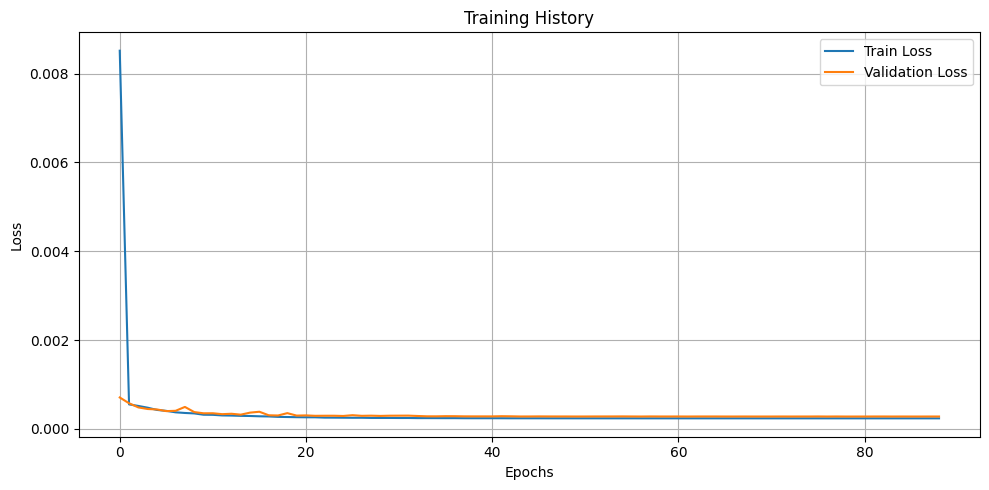

169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step
  Metric       Value
0    MSE    0.000575
1    MAE    0.019228
2   RMSE    0.023989
3     R2    0.553632
4   MAPE    3.708634
5  SMAPE    3.699980
6    SAE  103.579398


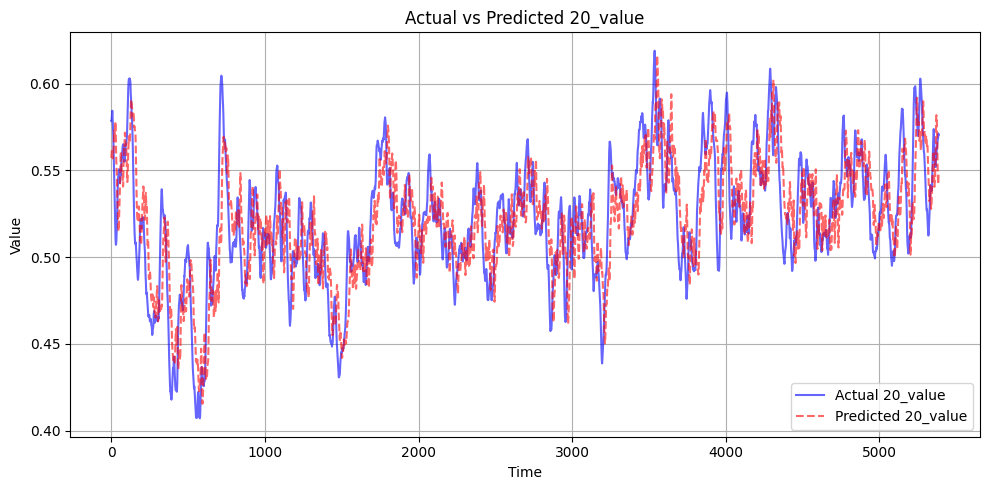

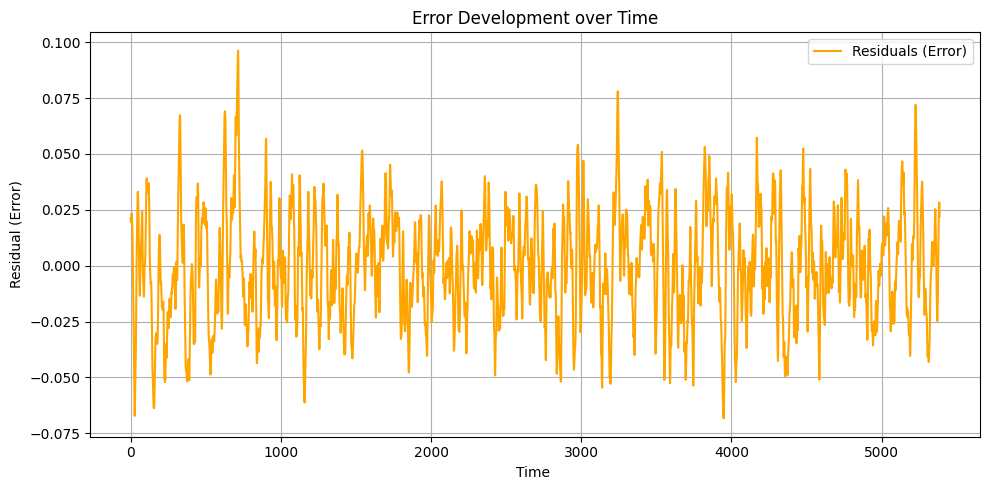

  Metric      Value
0    MSE   0.000142
1    MAE   0.010353
2   RMSE   0.011911
3     R2 -10.978196
4   MAPE   1.802428
5  SMAPE   1.824123
6    SAE   0.207060


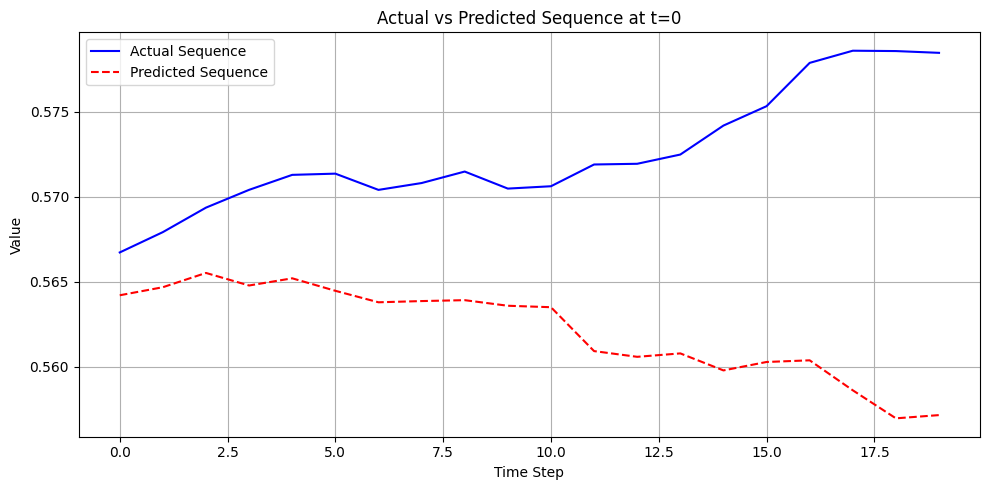

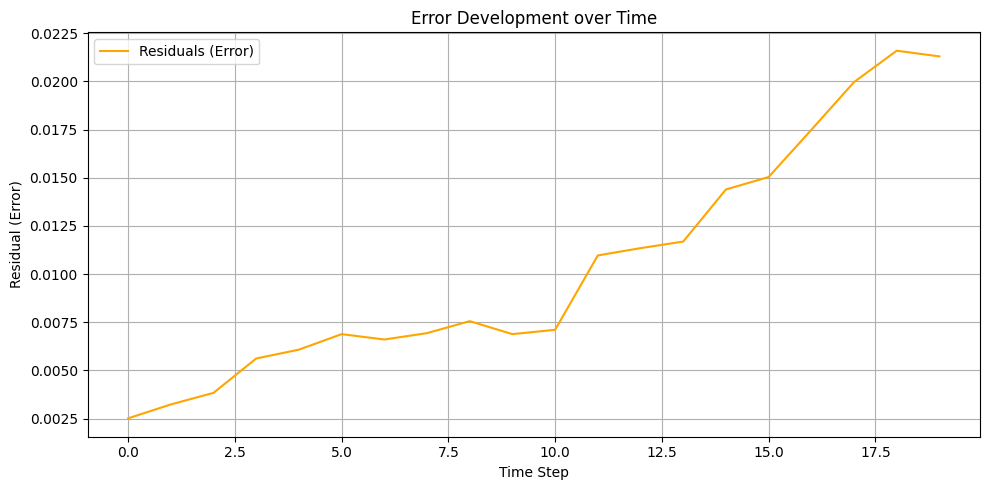

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


Registered model 'Direct_LSTM_Model_simple' already exists. Creating a new version of this model...
Created version '10' of model 'Direct_LSTM_Model_simple'.


In [117]:
run_direct_lstm_experiment(
    build_direct_lstm_model_simple,
    'simple',
    'direct_simple',
    X_train_dir,
    y_train_dir,
    X_val_dir,
    y_val_dir,
    X_test_dir,
    y_test_dir,
    20,epochs=100,lstm_units=64)

Direct Average 128 units

In [118]:
run_direct_lstm_experiment(
    build_direct_model_avg,
    'average',
    'direct_average',
    X_train_dir,
    y_train_dir,
    X_val_dir,
    y_val_dir,
    X_test_dir,
    y_test_dir,
    20,epochs=100,lstm_units=128)

(100, 1)


Model: "Avarege_Direct_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_27                │ (None, 100, 512)       │       528,384 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 128)            │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 859,156 (3.28 MB)

 Trainable params: 859,156 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 0.0183 - mae: 0.0860 - mse: 0.0183
Epoch 1: val_loss improved from inf to 0.00055, saving model to models/saved/Direct_LSTM_Model_average.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 187s 350ms/step - loss: 0.0182 - mae: 0.0859 - mse: 0.0182 - val_loss: 5.5038e-04 - val_mae: 0.0186 - val_mse: 5.5038e-04 - learning_rate: 0.0010
Epoch 2/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - loss: 0.0021 - mae: 0.0358 - mse: 0.0021
Epoch 2: val_loss improved from 0.00055 to 0.00041, saving model to models/saved/Direct_LSTM_Model_average.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 180s 349ms/step - loss: 0.0021 - mae: 0.0358 - mse: 0.0021 - val_loss: 4.0638e-04 - val_mae: 0.0155 - val_mse: 4.0638e-04 - learning_rate: 0.0010
Epoch 3/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - loss: 0.0014 - mae: 0.0297 - mse: 0.0014
Epoch 3: val_loss did not improve from 0.00041
517/517 ━━━━━━━━━━━━━━━━━━━━ 190s 368ms/step - loss: 0.0014 - mae: 0.0297 - mse: 0.0014

KeyboardInterrupt: 

Direct Average 64 units

(100, 1)


Model: "Avarege_Direct_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_28                │ (None, 100, 256)       │       133,120 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,596 (846.08 KB)

 Trainable params: 216,596 (846.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0280 - mae: 0.1096 - mse: 0.0280
Epoch 1: val_loss improved from inf to 0.00045, saving model to models/saved/Direct_LSTM_Model_average.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 56s 97ms/step - loss: 0.0279 - mae: 0.1096 - mse: 0.0279 - val_loss: 4.4670e-04 - val_mae: 0.0162 - val_mse: 4.4670e-04 - learning_rate: 0.0010
Epoch 2/100
516/517 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0030 - mae: 0.0432 - mse: 0.0030
Epoch 2: val_loss improved from 0.00045 to 0.00043, saving model to models/saved/Direct_LSTM_Model_average.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 47s 91ms/step - loss: 0.0030 - mae: 0.0432 - mse: 0.0030 - val_loss: 4.2678e-04 - val_mae: 0.0157 - val_mse: 4.2678e-04 - learning_rate: 0.0010
Epoch 3/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0019 - mae: 0.0342 - mse: 0.0019
Epoch 3: val_loss did not improve from 0.00043
517/517 ━━━━━━━━━━━━━━━━━━━━ 59s 115ms/step - loss: 0.0019 - mae: 0.0342 - mse: 0.0019 - val_

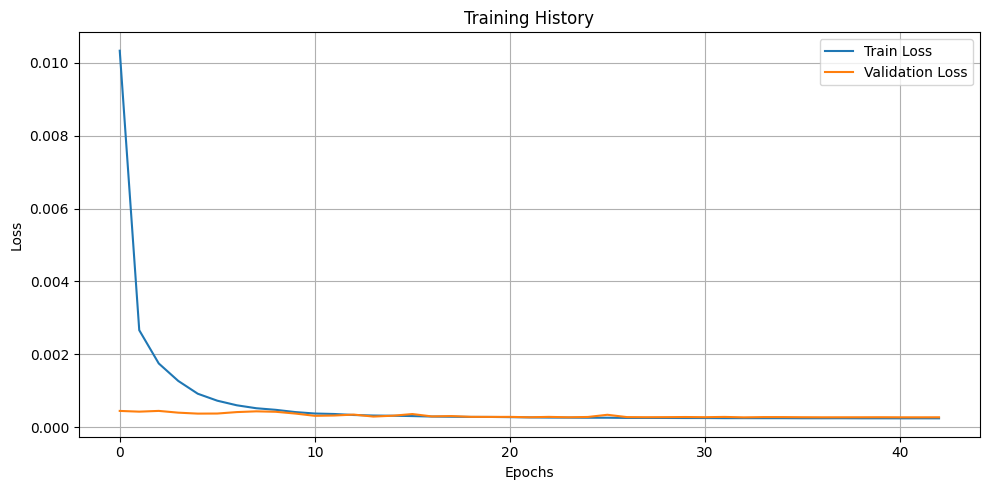

169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step
  Metric       Value
0    MSE    0.000553
1    MAE    0.018772
2   RMSE    0.023514
3     R2    0.571139
4   MAPE    3.613665
5  SMAPE    3.614448
6    SAE  101.125387


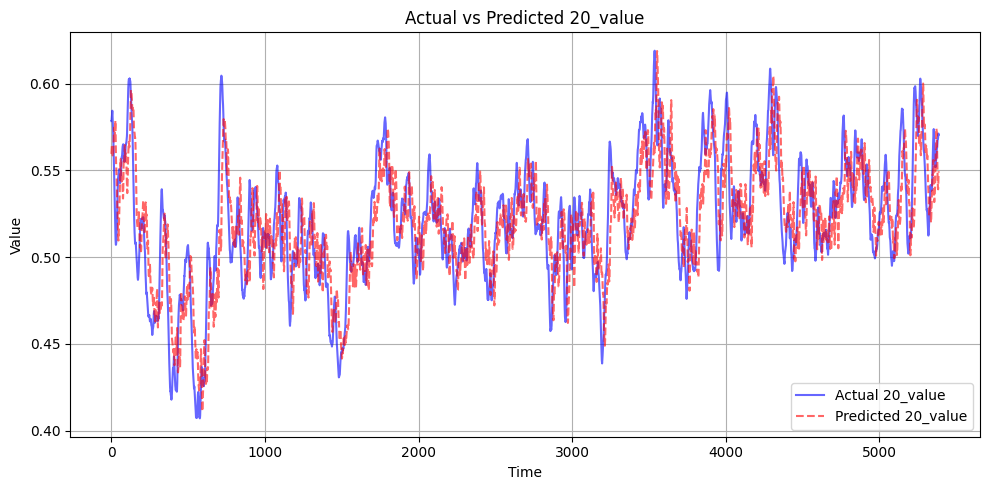

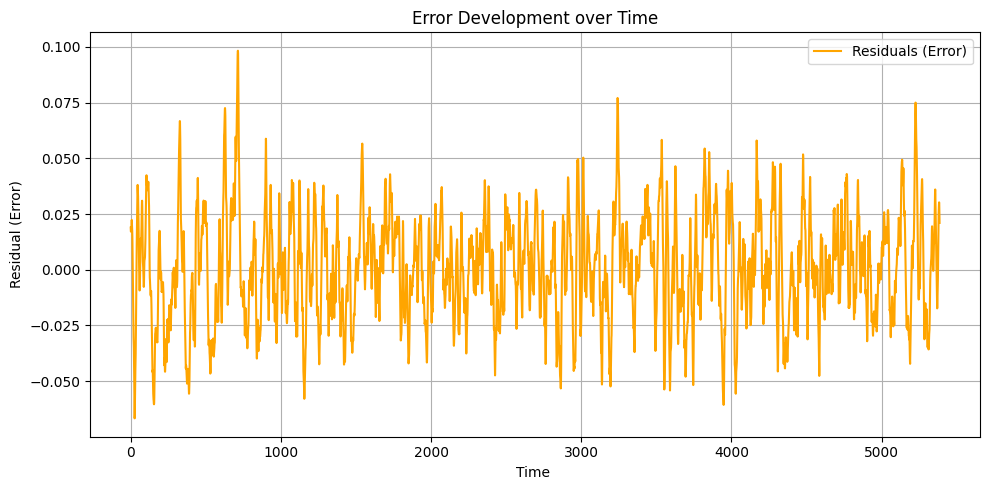

  Metric     Value
0    MSE  0.000101
1    MAE  0.008439
2   RMSE  0.010039
3     R2 -7.509707
4   MAPE  1.468545
5  SMAPE  1.483912
6    SAE  0.168783


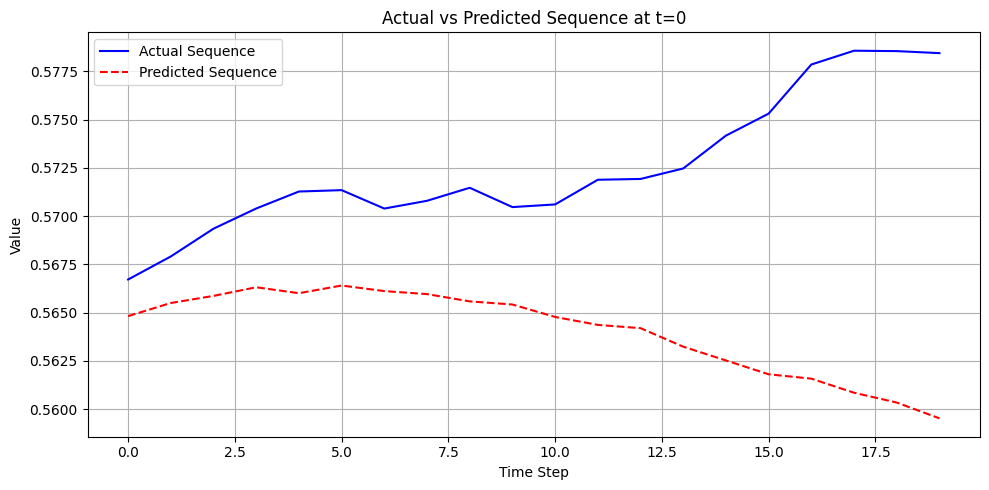

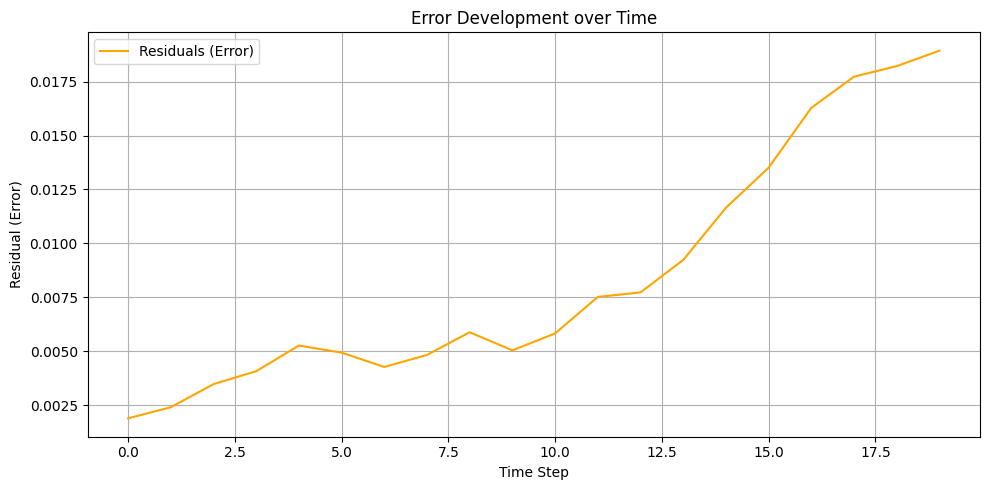

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


Registered model 'Direct_LSTM_Model_average' already exists. Creating a new version of this model...
Created version '8' of model 'Direct_LSTM_Model_average'.


In [119]:

run_direct_lstm_experiment(
    build_direct_model_avg,
    'average',
    'direct_average',
    X_train_dir,
    y_train_dir,
    X_val_dir,
    y_val_dir,
    X_test_dir,
    y_test_dir,
    20,epochs=100,lstm_units=64)

Direct Average 32 units

(100, 1)


Model: "Avarege_Direct_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_29                │ (None, 100, 128)       │        33,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_42 (LSTM)                  │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,060 (215.08 KB)

 Trainable params: 55,060 (215.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
516/517 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0527 - mae: 0.1585 - mse: 0.0527
Epoch 1: val_loss improved from inf to 0.00055, saving model to models/saved/Direct_LSTM_Model_average.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 43s 73ms/step - loss: 0.0526 - mae: 0.1582 - mse: 0.0526 - val_loss: 5.4973e-04 - val_mae: 0.0184 - val_mse: 5.4973e-04 - learning_rate: 0.0010
Epoch 2/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0046 - mae: 0.0530 - mse: 0.0046
Epoch 2: val_loss improved from 0.00055 to 0.00045, saving model to models/saved/Direct_LSTM_Model_average.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - loss: 0.0046 - mae: 0.0530 - mse: 0.0046 - val_loss: 4.4930e-04 - val_mae: 0.0163 - val_mse: 4.4930e-04 - learning_rate: 0.0010
Epoch 3/100
516/517 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0028 - mae: 0.0415 - mse: 0.0028
Epoch 3: val_loss did not improve from 0.00045
517/517 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - loss: 0.0028 - mae: 0.0415 - mse: 0.0028 - val_lo

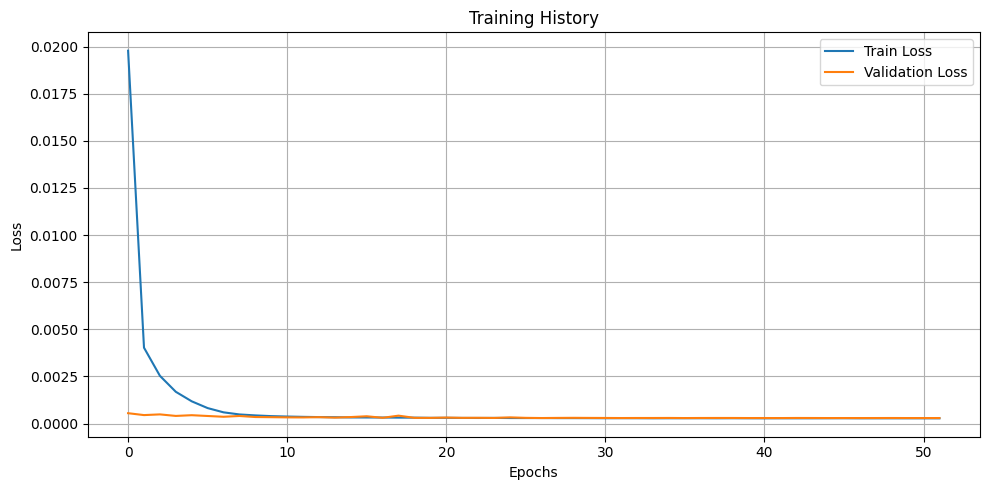

169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step
  Metric       Value
0    MSE    0.000565
1    MAE    0.019077
2   RMSE    0.023761
3     R2    0.562062
4   MAPE    3.688668
5  SMAPE    3.671318
6    SAE  102.770329


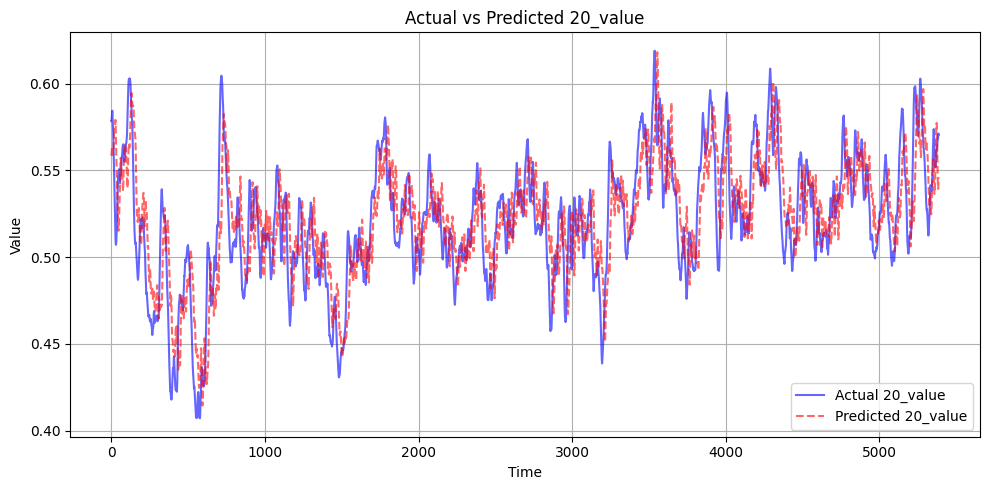

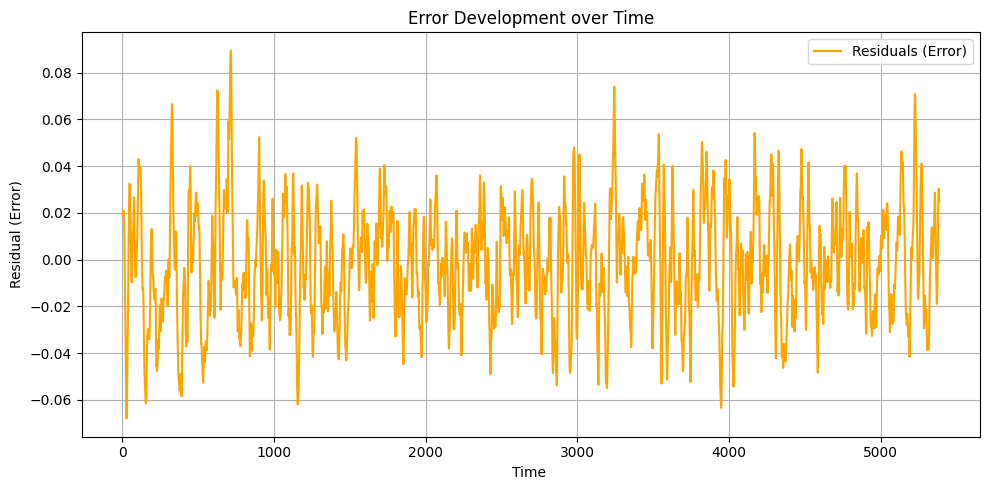

  Metric      Value
0    MSE   0.000143
1    MAE   0.010750
2   RMSE   0.011938
3     R2 -11.032341
4   MAPE   1.872430
5  SMAPE   1.894233
6    SAE   0.215000


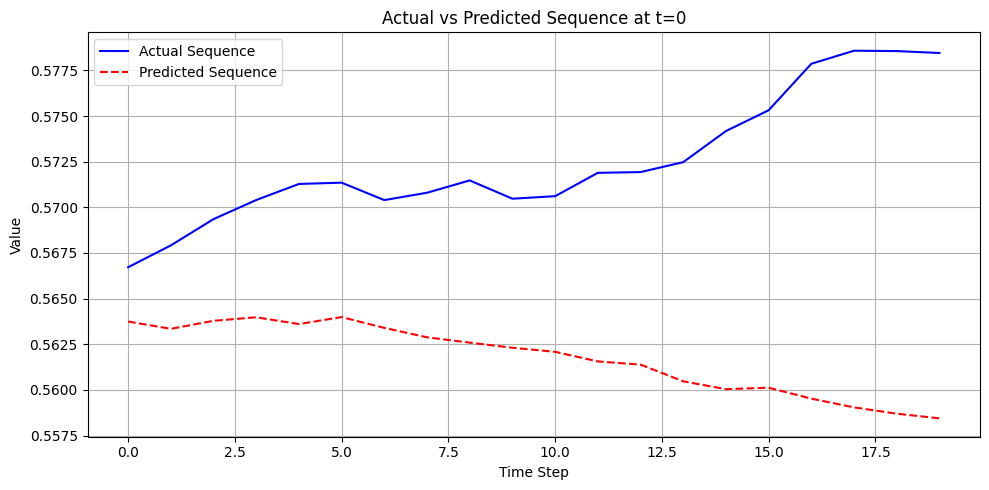

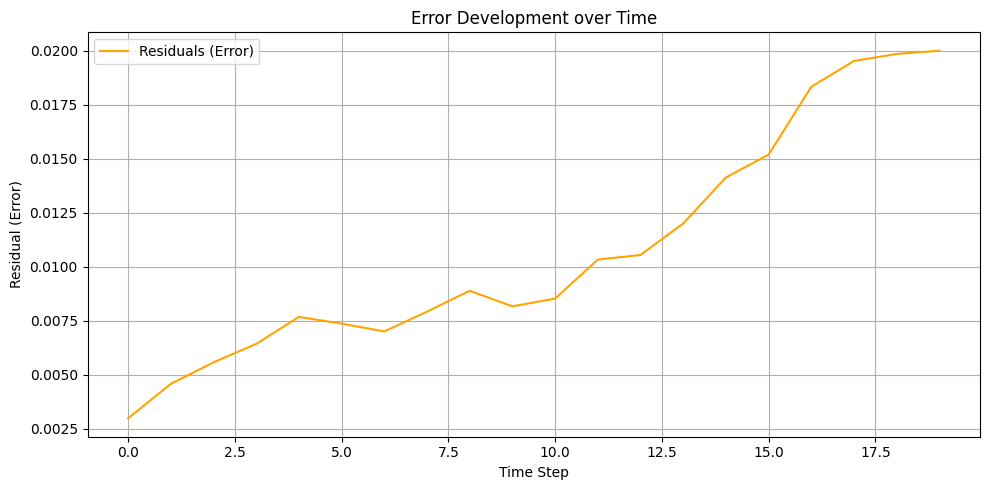

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


Registered model 'Direct_LSTM_Model_average' already exists. Creating a new version of this model...
Created version '9' of model 'Direct_LSTM_Model_average'.


In [120]:
run_direct_lstm_experiment(
    build_direct_model_avg,
    'average',
    'direct_average',
    X_train_dir,
    y_train_dir,
    X_val_dir,
    y_val_dir,
    X_test_dir,
    y_test_dir,
    20,epochs=100,lstm_units=32)

Direct Advanced

(100, 1)


Model: "Advanced_Direct_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidir_lstm_1 (Bidirectional)    │ (None, 100, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,892 (233.95 KB)

 Trainable params: 59,572 (232.70 KB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1421 - mae: 0.2520 - mse: 0.1421
Epoch 1: val_loss improved from inf to 0.00564, saving model to models/saved/Direct_LSTM_Model_advanced.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 66s 91ms/step - loss: 0.1419 - mae: 0.2518 - mse: 0.1419 - val_loss: 0.0056 - val_mae: 0.0644 - val_mse: 0.0056 - learning_rate: 0.0010
Epoch 2/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0040 - mae: 0.0491 - mse: 0.0040
Epoch 2: val_loss improved from 0.00564 to 0.00395, saving model to models/saved/Direct_LSTM_Model_advanced.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 46s 89ms/step - loss: 0.0040 - mae: 0.0491 - mse: 0.0040 - val_loss: 0.0040 - val_mae: 0.0556 - val_mse: 0.0040 - learning_rate: 0.0010
Epoch 3/100
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0022 - mae: 0.0364 - mse: 0.0022
Epoch 3: val_loss improved from 0.00395 to 0.00085, saving model to models/saved/Direct_LSTM_Model_advanced.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 48s 93ms/ste

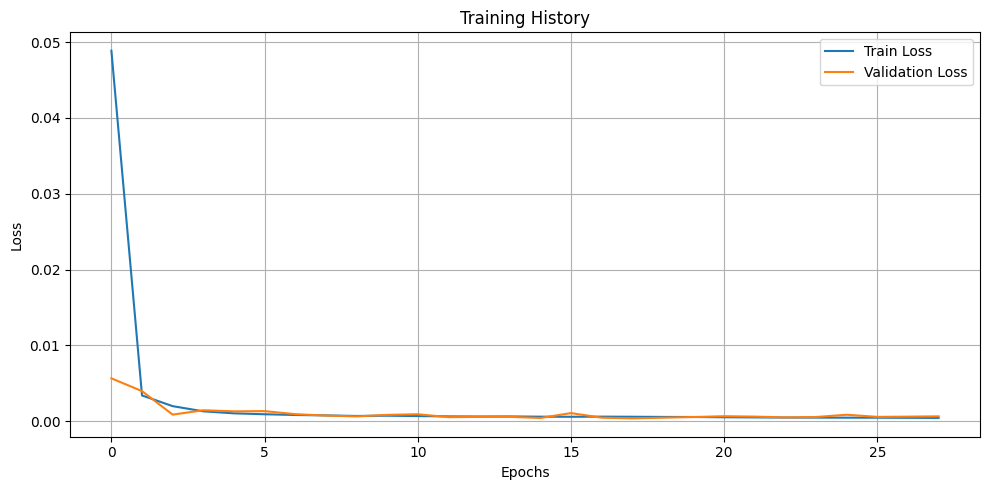

169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step
  Metric       Value
0    MSE    0.000601
1    MAE    0.019276
2   RMSE    0.024510
3     R2    0.534020
4   MAPE    3.693169
5  SMAPE    3.716794
6    SAE  103.839941


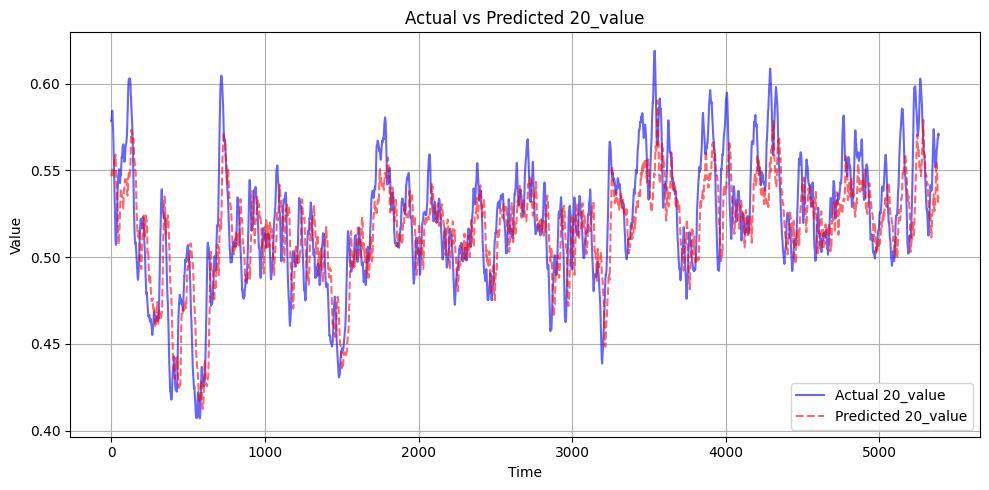

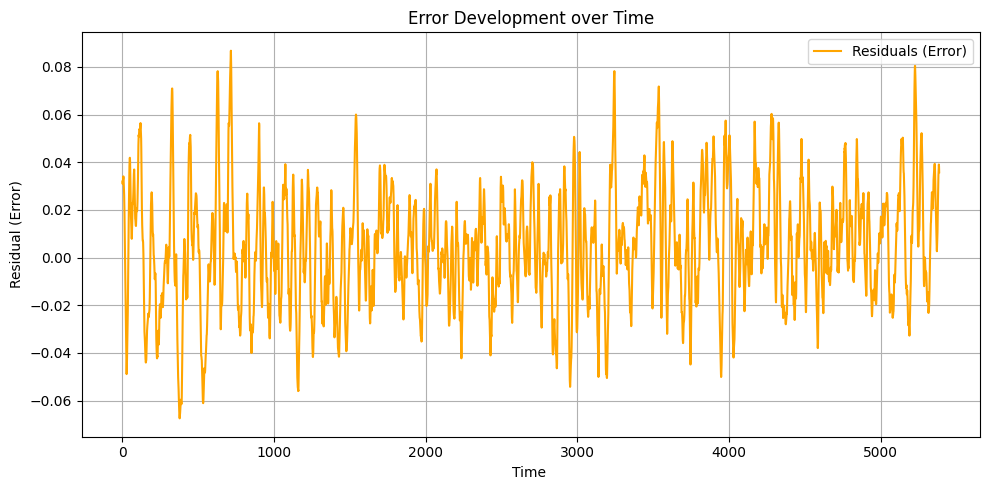

  Metric      Value
0    MSE   0.000656
1    MAE   0.025283
2   RMSE   0.025621
3     R2 -54.425348
4   MAPE   4.412048
5  SMAPE   4.514181
6    SAE   0.505651


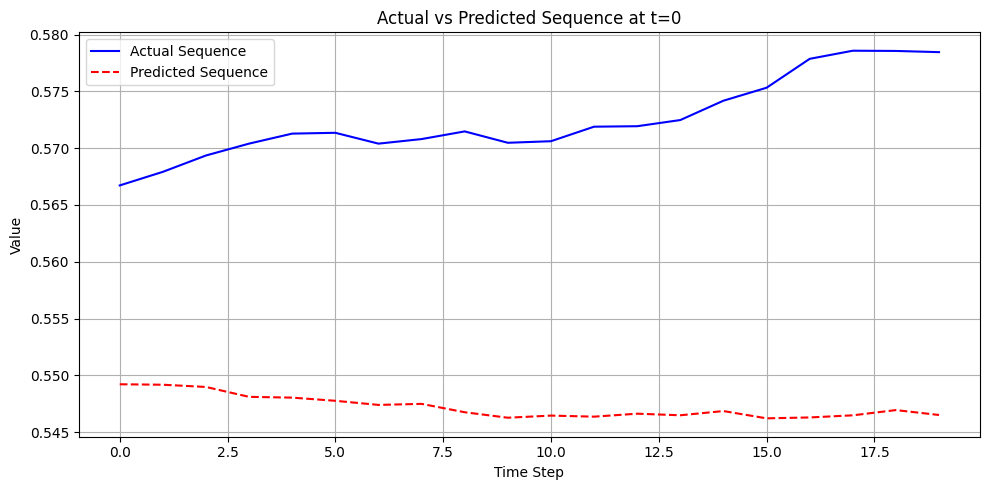

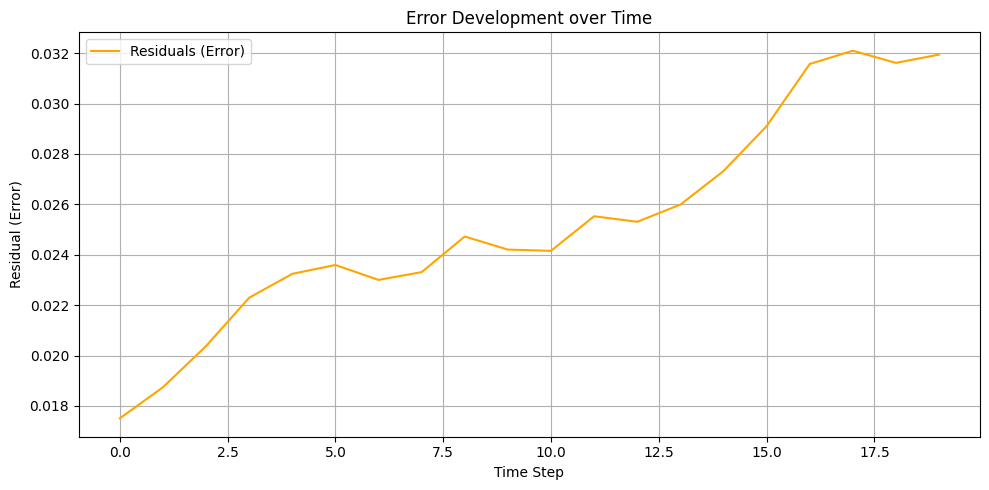

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


Registered model 'Direct_LSTM_Model_advanced' already exists. Creating a new version of this model...
Created version '5' of model 'Direct_LSTM_Model_advanced'.


In [121]:
run_direct_lstm_experiment(
    build_advanced_direct_lstm,
    'advanced',
    'direct_advanced',
    X_train_dir,
    y_train_dir,
    X_val_dir,
    y_val_dir,
    X_test_dir,
    y_test_dir,
    20,epochs=100,lstm_units=64)

Recursive Model

In [ ]:
from src.autoregression.models.RecurLSTM import build_recursive_lstm_simple


Recursive Simple

Model: "Recursive_LSTM_Model_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
515/517 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0121 - mae: 0.0486 - mse: 0.0121
Epoch 1: val_loss improved from inf to 0.00015, saving model to models/saved/Recursive_LSTM_Model_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - loss: 0.0121 - mae: 0.0484 - mse: 0.0121 - val_loss: 1.4658e-04 - val_mae: 0.0097 - val_mse: 1.4658e-04 - learning_rate: 0.0010
Epoch 2/100
516/517 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.1000e-04 - mae: 0.0082 - mse: 1.1000e-04
Epoch 2: val_loss improved from 0.00015 to 0.00010, saving model to models/saved/Recursive_LSTM_Model_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - loss: 1.0998e-04 - mae: 0.0082 - mse: 1.0998e-04 - val_loss: 9.6700e-05 - val_mae: 0.0079 - val_mse: 9.6700e-05 - learning_rate: 0.0010
Epoch 3/100
516/517 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 9.2376e-05 - mae: 0.0075 - mse: 9.2376e-05
Epoch 3: val_loss improved from 0.00010 to 0.00007, saving model to models/saved/Recursive_LSTM_Model_simple.kera

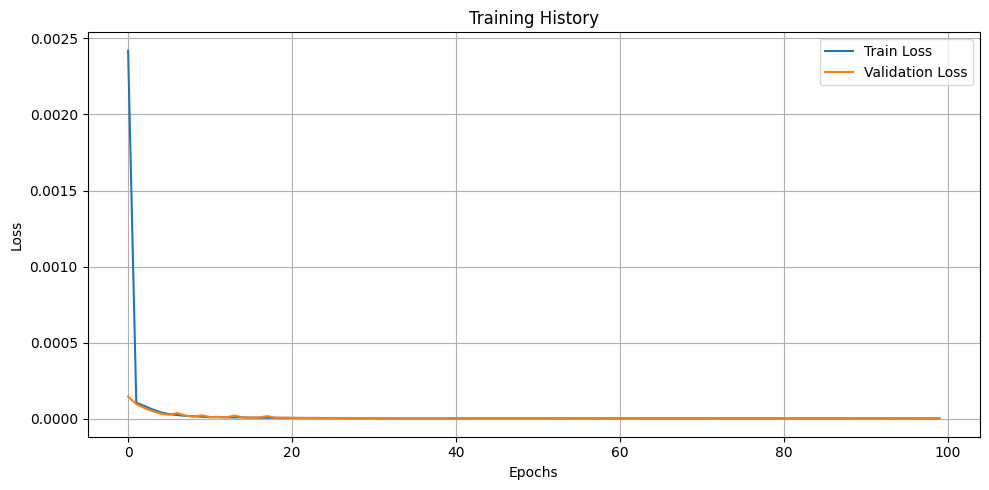

  Metric      Value
0    MSE   0.000557
1    MAE   0.018670
2   RMSE   0.023594
3     R2   0.563545
4   MAPE   3.609207
5  SMAPE   3.610673
6    SAE  93.348354


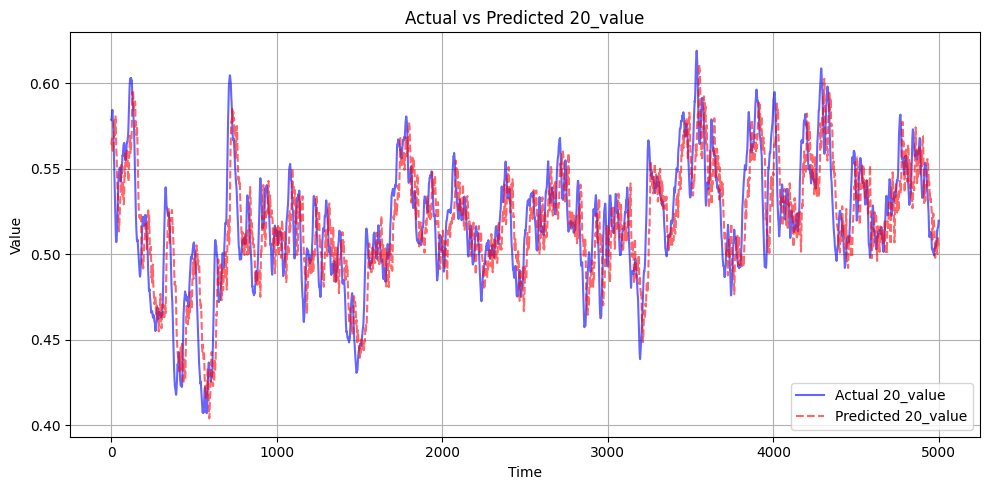

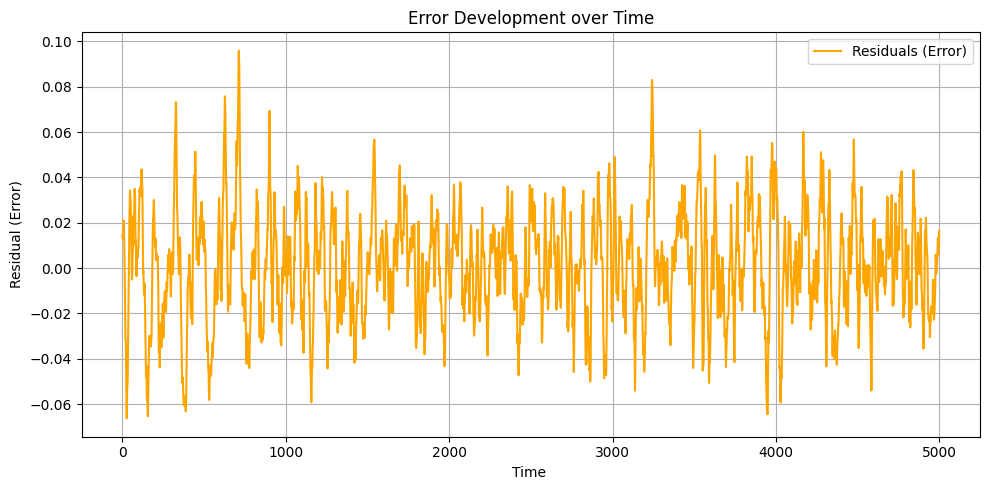

  Metric     Value
0    MSE  0.000052
1    MAE  0.005689
2   RMSE  0.007237
3     R2 -3.421876
4   MAPE  0.989250
5  SMAPE  0.997198
6    SAE  0.113790


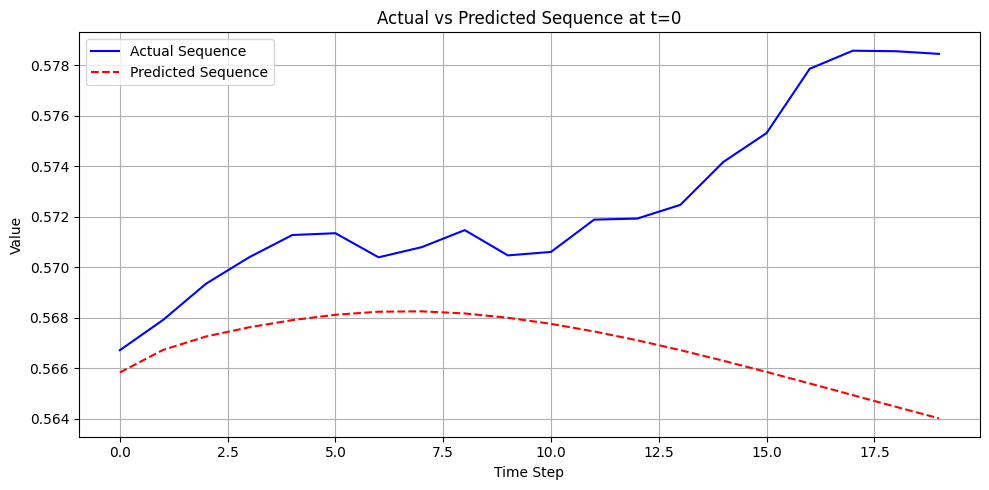

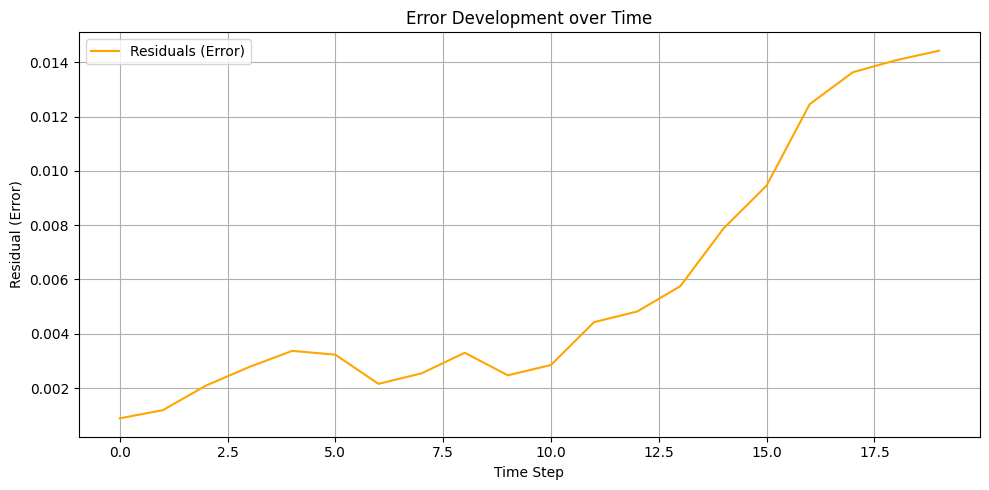

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


Registered model 'Recursive_LSTM_Model_simple' already exists. Creating a new version of this model...
Created version '3' of model 'Recursive_LSTM_Model_simple'.


In [161]:
run_recursive_lstm_experiment(
    build_recursive_lstm_simple,
    'simple',
    'recursive_simple',
    X_train_rec,
    y_train_rec,
    X_val_rec,
    y_val_rec,
    X_test_rec,
    y_test_dir,
    n_predicted_rows=5000,
    output_steps=20,
    epochs=100)

Hybrid Model

In [ ]:
from src.autoregression.utils_ar import run_direct_refiner_experiment
from src.autoregression.models.RefineLSTM import build_refinement_cnn_model_simple,build_refinement_lstm_model_simple,build_average_refinement_lstm
import mlflow.keras

Hybrid: Direct Simple + Refine LSTM Simple 

c:\SVN\Python projects\Thesis Project\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 7 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


517/517 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step
173/173 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step
(20, 1)


Model: "Refinement_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ refinement_input (InputLayer)   │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ refinement_lstm (LSTM)          │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ refined_20th_output (Dense)     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
515/517 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0130 - mae: 0.0548 - mse: 0.0130
Epoch 1: val_loss improved from inf to 0.00063, saving model to models/saved/Direct_Refiner_Model_simple_lstm_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - loss: 0.0129 - mae: 0.0547 - mse: 0.0129 - val_loss: 6.3124e-04 - val_mae: 0.0201 - val_mse: 6.3124e-04 - learning_rate: 0.0010
Epoch 2/30
515/517 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5.1268e-04 - mae: 0.0177 - mse: 5.1268e-04
Epoch 2: val_loss improved from 0.00063 to 0.00059, saving model to models/saved/Direct_Refiner_Model_simple_lstm_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - loss: 5.1273e-04 - mae: 0.0177 - mse: 5.1273e-04 - val_loss: 5.8629e-04 - val_mae: 0.0195 - val_mse: 5.8629e-04 - learning_rate: 0.0010
Epoch 3/30
514/517 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.2618e-04 - mae: 0.0179 - mse: 5.2618e-04
Epoch 3: val_loss improved from 0.00059 to 0.00058, saving model to models/saved/Direct_Refi

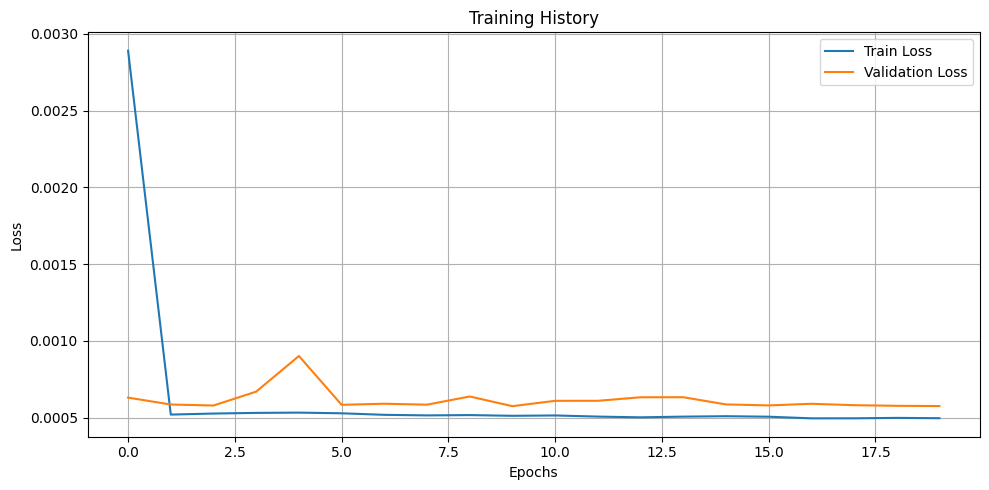

169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
  Metric      Value
0    MSE   0.000513
1    MAE   0.018144
2   RMSE   0.022641
3     R2   0.602405
4   MAPE   3.486175
5  SMAPE   3.494162
6    SAE  97.742684


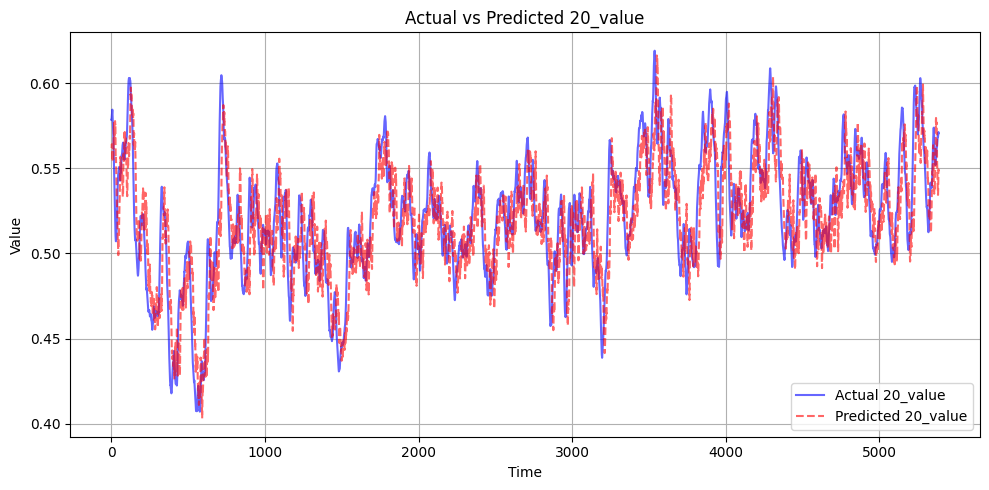

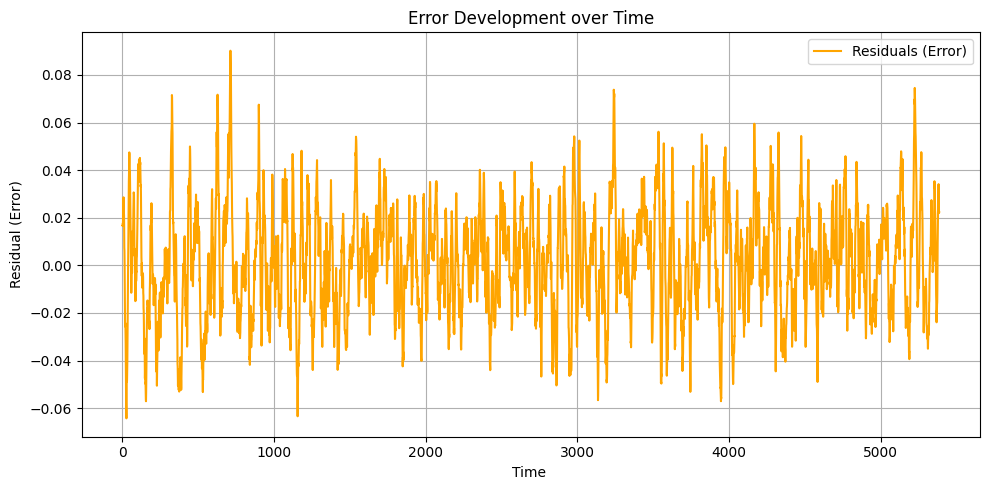

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


Registered model 'Direct_Refiner_Model_simple_lstm_simple' already exists. Creating a new version of this model...
Created version '7' of model 'Direct_Refiner_Model_simple_lstm_simple'.


In [233]:
dir_model = mlflow.keras.load_model("models:/simple new data/1") 

run_direct_refiner_experiment(build_refinement_lstm_model_simple,
                              dir_model,
                              'simple_lstm_simple',
                              'ref_simple_lstm_simple',
                              X_train_dir=X_train_dir,
                              X_test_dir=X_test_dir,
                              X_val_dir=X_val_dir,
                              y_test_dir=y_test_dir,
                              y_train_dir=y_train_dir,
                              y_val_dir=y_val_dir,
                              output_steps=20,
                              units=64)

Hybrid: Direct Simple + Refine CNN Simple 

517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step
173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step
(20, 1)


Model: "Base_CNN_Refiner"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ refinement_input (InputLayer)   │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 18, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 16)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ refined_output (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
516/517 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0587 - mae: 0.1454
Epoch 1: val_loss improved from inf to 0.00173, saving model to models/saved/Direct_Refiner_Model_simple_cnn_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0586 - mae: 0.1451 - val_loss: 0.0017 - val_mae: 0.0350 - learning_rate: 0.0010
Epoch 2/30
510/517 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.3102e-04 - mae: 0.0215
Epoch 2: val_loss improved from 0.00173 to 0.00095, saving model to models/saved/Direct_Refiner_Model_simple_cnn_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.3036e-04 - mae: 0.0215 - val_loss: 9.5189e-04 - val_mae: 0.0250 - learning_rate: 0.0010
Epoch 3/30
514/517 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.8465e-04 - mae: 0.0189
Epoch 3: val_loss improved from 0.00095 to 0.00079, saving model to models/saved/Direct_Refiner_Model_simple_cnn_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.8452e-04 - mae: 0.0189 - val_loss: 7.9131e-04 - val_ma

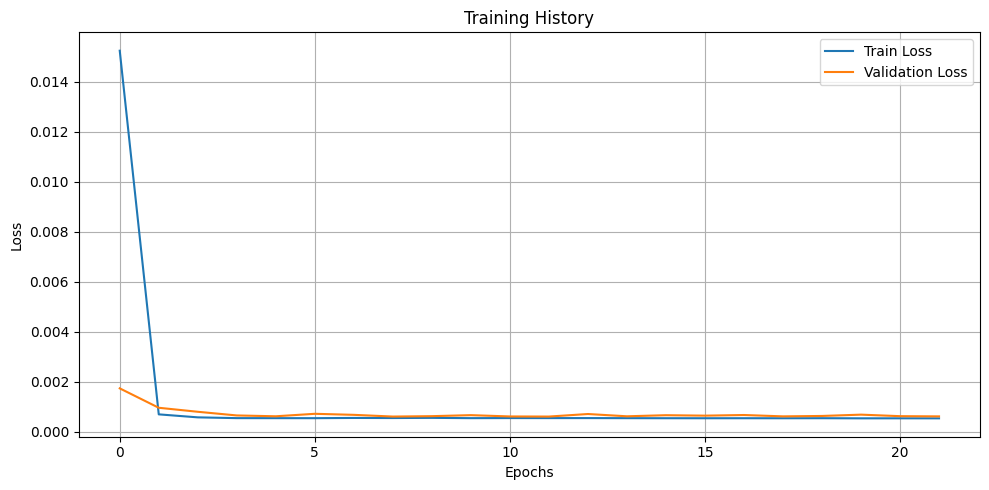

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Metric       Value
0    MSE    0.000558
1    MAE    0.018967
2   RMSE    0.023633
3     R2    0.566799
4   MAPE    3.629002
5  SMAPE    3.656800
6    SAE  102.177266


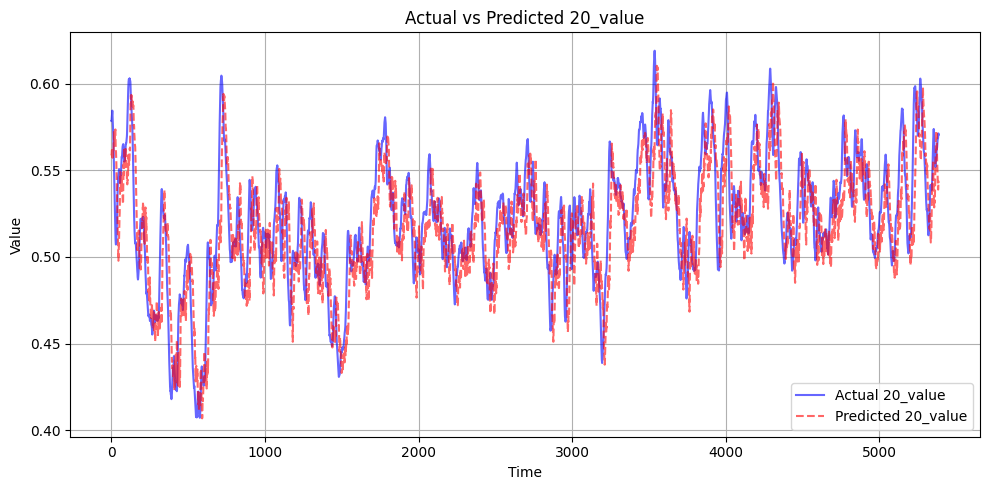

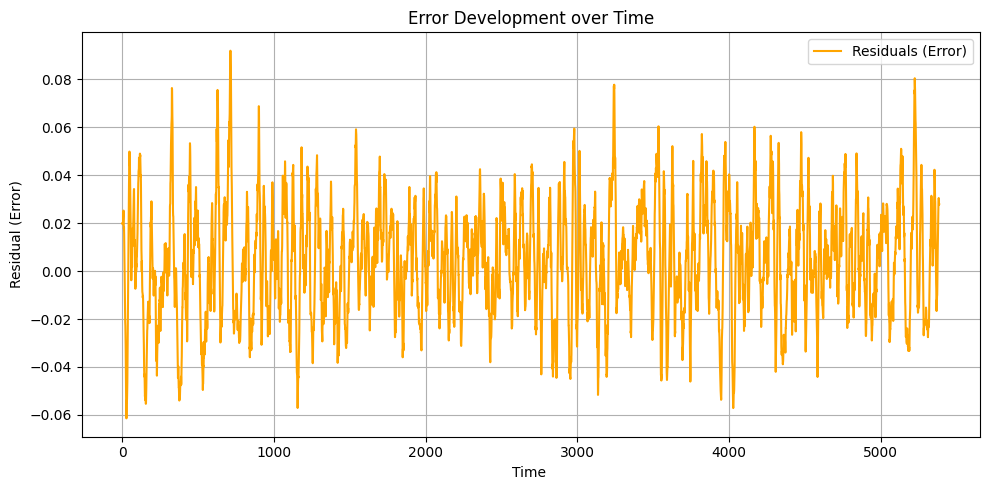

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


Registered model 'Direct_Refiner_Model_simple_cnn_simple' already exists. Creating a new version of this model...
Created version '8' of model 'Direct_Refiner_Model_simple_cnn_simple'.


In [234]:

run_direct_refiner_experiment(build_refinement_cnn_model_simple,
                              dir_model,
                              'simple_cnn_simple',
                              'ref_simple_cnn_simple',
                              X_train_dir=X_train_dir,
                              X_test_dir=X_test_dir,
                              X_val_dir=X_val_dir,
                              y_test_dir=y_test_dir,
                              y_train_dir=y_train_dir,
                              y_val_dir=y_val_dir,
                              output_steps=20,
                              units=32)

Hybrid: Direct Simple + Refine LSTM Average

517/517 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step
173/173 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step
(20, 1)


Model: "Refiner_LSTM_Average"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ refinement_input (InputLayer)   │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_61 (LSTM)                  │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_62 (LSTM)                  │ (None, 20, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_63 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,465 (126.82 KB)

 Trainable params: 32,465 (126.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0171 - mae: 0.0906 - mse: 0.0171
Epoch 1: val_loss improved from inf to 0.00061, saving model to models/saved/Direct_Refiner_Model_simple_lstm_avg.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 0.0170 - mae: 0.0905 - mse: 0.0170 - val_loss: 6.1022e-04 - val_mae: 0.0198 - val_mse: 6.1022e-04 - learning_rate: 0.0010
Epoch 2/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0043 - mae: 0.0516 - mse: 0.0043
Epoch 2: val_loss did not improve from 0.00061
517/517 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - loss: 0.0043 - mae: 0.0516 - mse: 0.0043 - val_loss: 9.8853e-04 - val_mae: 0.0254 - val_mse: 9.8853e-04 - learning_rate: 0.0010
Epoch 3/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0029 - mae: 0.0418 - mse: 0.0029
Epoch 3: val_loss did not improve from 0.00061
517/517 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - loss: 0.0029 - mae: 0.0418 - mse: 0.0029 - val_loss: 6.3396e-04 - val_mae: 0.0202 - val_mse: 6.3396e-04 - l

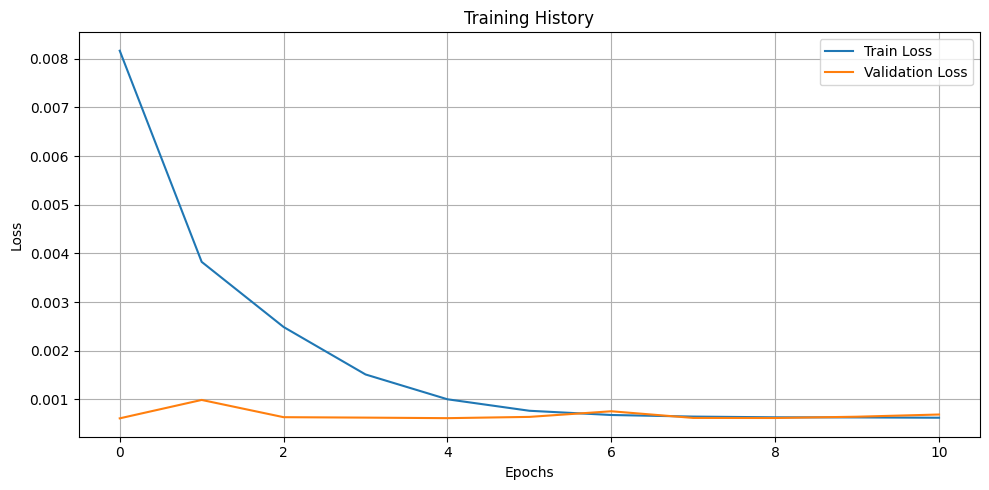

169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
  Metric       Value
0    MSE    0.000557
1    MAE    0.018915
2   RMSE    0.023602
3     R2    0.567916
4   MAPE    3.620684
5  SMAPE    3.646339
6    SAE  101.894168


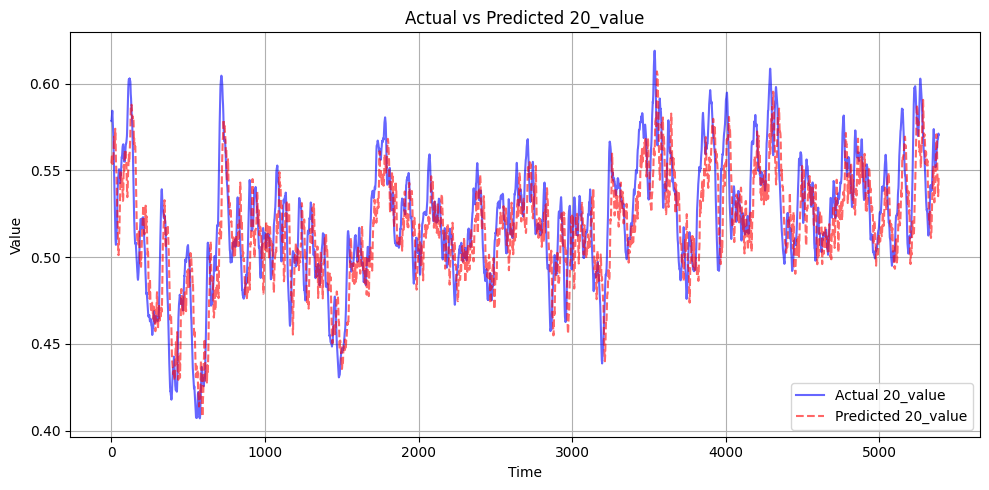

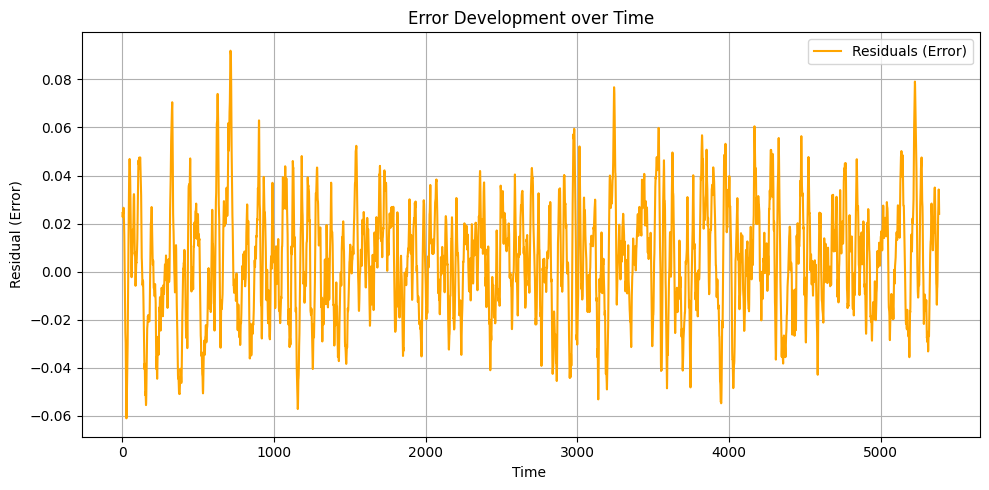

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


Registered model 'Direct_Refiner_Model_simple_lstm_avg' already exists. Creating a new version of this model...
Created version '8' of model 'Direct_Refiner_Model_simple_lstm_avg'.


In [ ]:
import importlib
from src.autoregression.models import RefineLSTM
importlib.reload(RefineLSTM)
from src.autoregression.models.RefineLSTM import build_average_refinement_lstm
dir_model = mlflow.keras.load_model("models:/Direct_LSTM_Model_simple_new_data/1") 

run_direct_refiner_experiment(build_average_refinement_lstm,
                              dir_model,
                              'simple_lstm_avg',
                              'ref_simple_lstm_avg',
                              X_train_dir=X_train_dir,
                              X_test_dir=X_test_dir,
                              X_val_dir=X_val_dir,
                              y_test_dir=y_test_dir,
                              y_train_dir=y_train_dir,
                              y_val_dir=y_val_dir,
                              output_steps=20,
                              units=64)

Hybrid: Direct Average + Refine LSTM Simple 

Model: "Avarege_Direct_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_28                │ (None, 100, 256)       │       133,120 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,790 (2.48 MB)

 Trainable params: 216,596 (846.08 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ refinement_input (InputLayer)   │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ refinement_lstm (LSTM)          │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ refined_20th_output (Dense)     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
511/517 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0081 - mae: 0.0462 - mse: 0.0081
Epoch 1: val_loss improved from inf to 0.00068, saving model to models/saved/Direct_Refiner_Model_avg_lstm_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0080 - mae: 0.0459 - mse: 0.0080 - val_loss: 6.7604e-04 - val_mae: 0.0207 - val_mse: 6.7604e-04 - learning_rate: 0.0010
Epoch 2/30
513/517 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.6618e-04 - mae: 0.0186 - mse: 5.6618e-04
Epoch 2: val_loss improved from 0.00068 to 0.00063, saving model to models/saved/Direct_Refiner_Model_avg_lstm_simple.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.6626e-04 - mae: 0.0186 - mse: 5.6626e-04 - val_loss: 6.2682e-04 - val_mae: 0.0200 - val_mse: 6.2682e-04 - learning_rate: 0.0010
Epoch 3/30
515/517 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.6421e-04 - mae: 0.0185 - mse: 5.6421e-04
Epoch 3: val_loss did not improve from 0.00063
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.6422e-

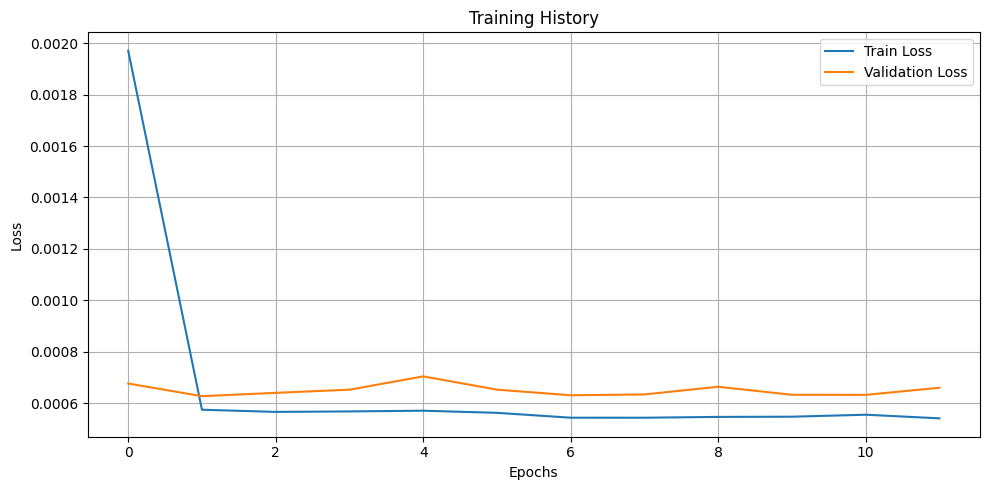

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
  Metric       Value
0    MSE    0.000547
1    MAE    0.018708
2   RMSE    0.023389
3     R2    0.575666
4   MAPE    3.597065
5  SMAPE    3.600238
6    SAE  100.778629


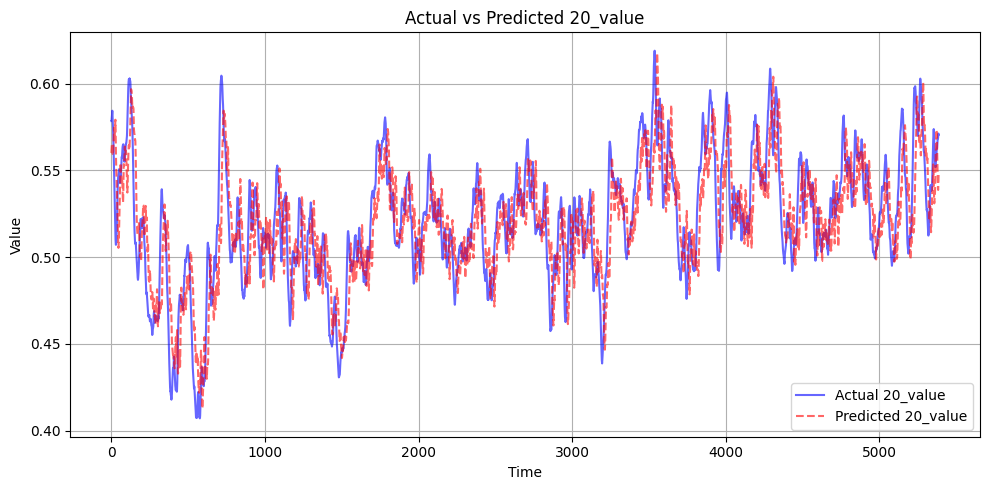

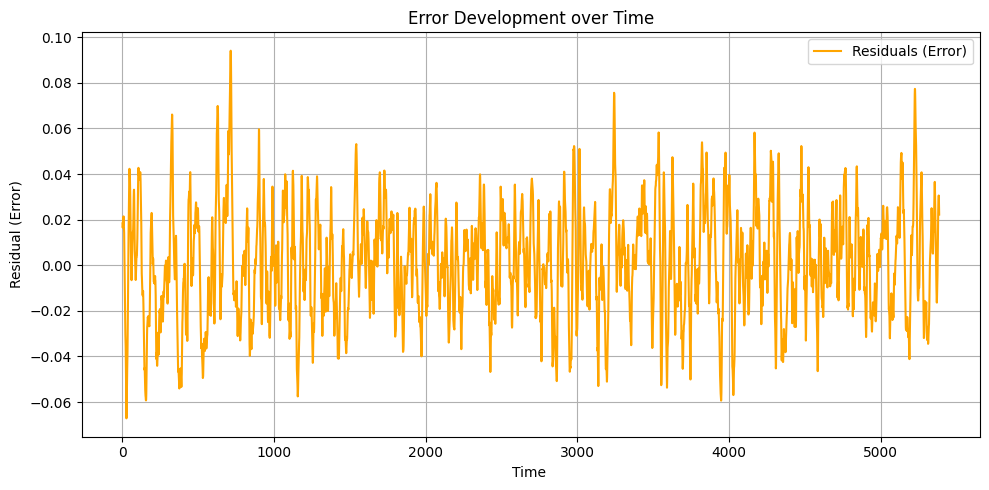

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


Registered model 'Direct_Refiner_Model_avg_lstm_simple' already exists. Creating a new version of this model...
Created version '5' of model 'Direct_Refiner_Model_avg_lstm_simple'.


In [131]:
dir_model_av = mlflow.keras.load_model("models:/Direct_LSTM_Model_average/8") 
dir_model_av.summary()
run_direct_refiner_experiment(build_refinement_lstm_model_simple,
                              dir_model_av,
                              'avg_lstm_simple',
                              'ref_avg_lstm_simple',
                              X_train_dir=X_train_dir,
                              X_test_dir=X_test_dir,
                              X_val_dir=X_val_dir,
                              y_test_dir=y_test_dir,
                              y_train_dir=y_train_dir,
                              y_val_dir=y_val_dir,
                              output_steps=20,
                              units=64)

Hybrid: Direct Average + Refine LSTM Average 

517/517 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step
(20, 1)


Model: "Refiner_LSTM_Average"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ refinement_input (InputLayer)   │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_48 (LSTM)                  │ (None, 20, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,465 (126.82 KB)

 Trainable params: 32,465 (126.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
516/517 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0286 - mae: 0.1095 - mse: 0.0286
Epoch 1: val_loss improved from inf to 0.00111, saving model to models/saved/Direct_Refiner_Model_avg_lstm_avg.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - loss: 0.0286 - mae: 0.1094 - mse: 0.0286 - val_loss: 0.0011 - val_mae: 0.0272 - val_mse: 0.0011 - learning_rate: 0.0010
Epoch 2/30
515/517 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0049 - mae: 0.0551 - mse: 0.0049
Epoch 2: val_loss improved from 0.00111 to 0.00080, saving model to models/saved/Direct_Refiner_Model_avg_lstm_avg.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0049 - mae: 0.0550 - mse: 0.0049 - val_loss: 7.9971e-04 - val_mae: 0.0228 - val_mse: 7.9971e-04 - learning_rate: 0.0010
Epoch 3/30
516/517 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0031 - mae: 0.0440 - mse: 0.0031
Epoch 3: val_loss improved from 0.00080 to 0.00065, saving model to models/saved/Direct_Refiner_Model_avg_lstm_avg.keras
517/517 ━━━━━━━

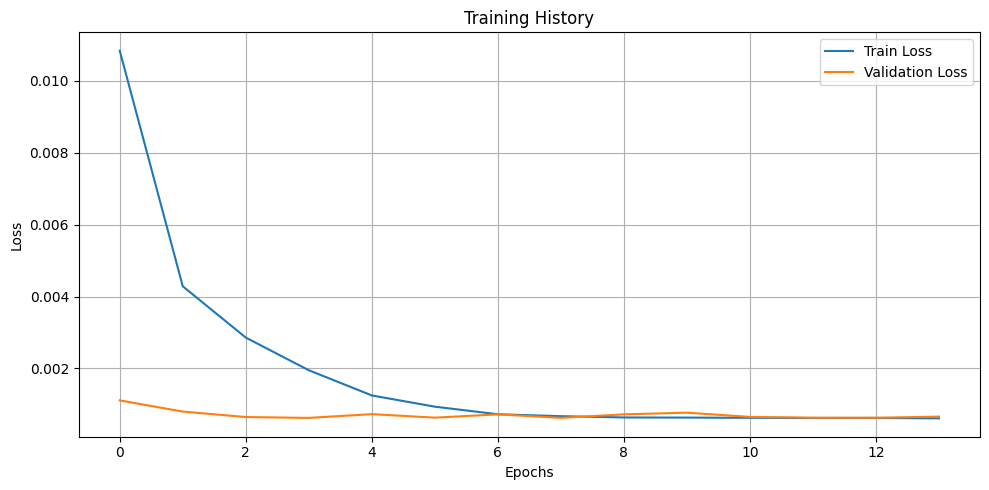

169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
  Metric       Value
0    MSE    0.000548
1    MAE    0.018763
2   RMSE    0.023411
3     R2    0.574871
4   MAPE    3.600466
5  SMAPE    3.612591
6    SAE  101.078178


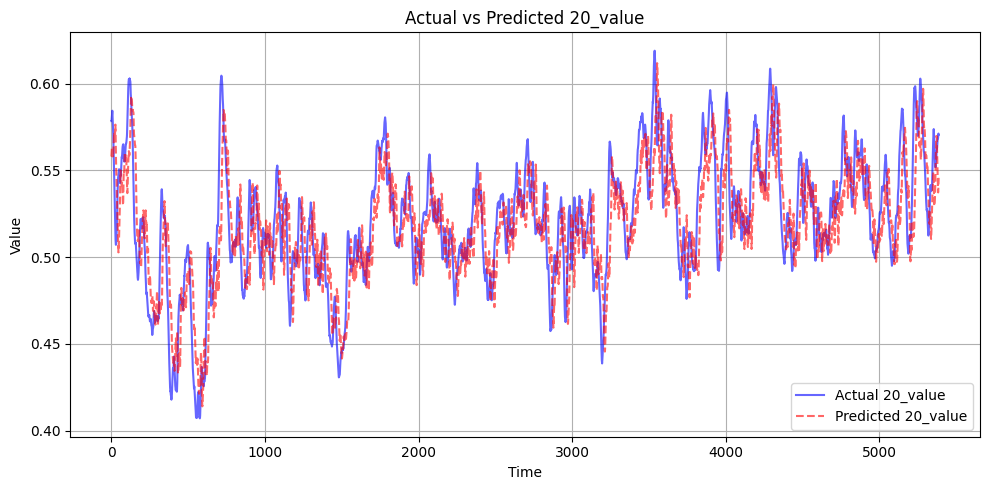

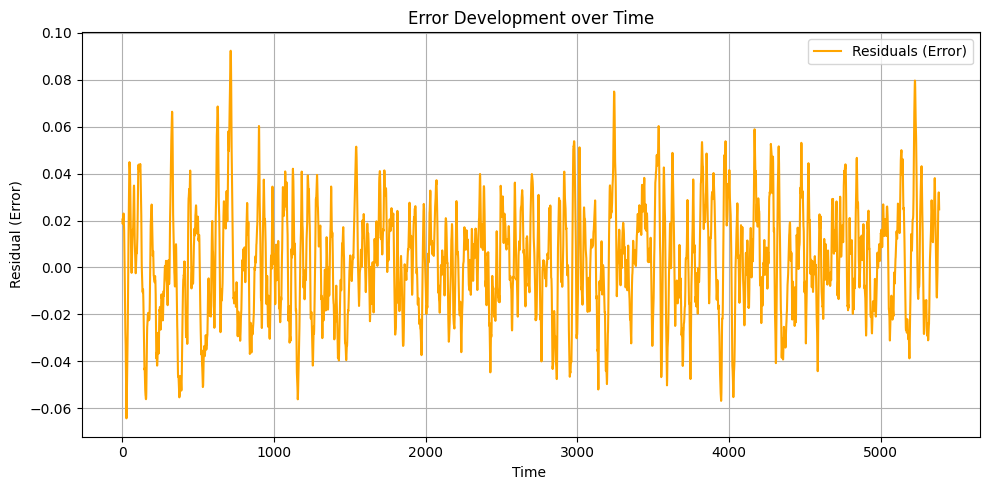

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


Registered model 'Direct_Refiner_Model_avg_lstm_avg' already exists. Creating a new version of this model...
Created version '6' of model 'Direct_Refiner_Model_avg_lstm_avg'.


In [132]:
dir_model_av = mlflow.keras.load_model("models:/Direct_LSTM_Model_average/8") 

run_direct_refiner_experiment(build_average_refinement_lstm,
                              dir_model_av,
                              'avg_lstm_avg',
                              'ref_avg_lstm_avg',
                              X_train_dir=X_train_dir,
                              X_test_dir=X_test_dir,
                              X_val_dir=X_val_dir,
                              y_test_dir=y_test_dir,
                              y_train_dir=y_train_dir,
                              y_val_dir=y_val_dir,
                              output_steps=20,
                              units=64)

In [63]:
import numpy as np

def prepare_20th_step_lstm_data(series, input_len=100, output_step=20):
    """
    Prepare data for LSTM where the target is only the 20th future step ahead.

    Inputs:
        series (np.ndarray): 1D time series
        input_len (int): Length of input window (e.g., 100)
        output_step (int): Number of steps ahead to predict (e.g., 20)
    
    Returns:
        X_train_20, y_train_20, X_val_20, y_val_20, X_test_20, y_test_20
    """
    
    # Create lagged samples
    X, y = [], []
    for t in range(len(series) - input_len - output_step):
        X.append(series[t : t + input_len])  # Past `input_len` values
        y.append(series[t + input_len + output_step - 1])  # Only the 20th step ahead
    
    X = np.array(X)[..., np.newaxis]  # Shape: (samples, input_len, 1)
    y = np.array(y)                   # Shape: (samples,)

    # Split: 60% train, 20% val, 20% test
    n = len(X)
    train_end = int(n * 0.6)
    val_end = int(n * 0.8)

    X_train_20, y_train_20 = X[:train_end], y[:train_end]
    X_val_20, y_val_20     = X[train_end:val_end], y[train_end:val_end]
    X_test_20, y_test_20   = X[val_end:], y[val_end:]

    return X_train_20, y_train_20, X_val_20, y_val_20, X_test_20, y_test_20

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def build_lstm_20th_step(input_shape, lstm_units=64):
    """
    Builds an LSTM model that predicts ONLY the 20th step ahead.
    """
    model = Sequential([
        LSTM(lstm_units, return_sequences=False, input_shape=input_shape),
        Dense(128, activation="relu"),
        Dense(1)  # Single output: y[t+20]
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model



In [64]:
# Prepare data
# Prepare data
X_train_20, y_train_20, X_val_20, y_val_20, X_test_20, y_test_20 = prepare_20th_step_lstm_data(data)


# Build model
lstm_20_model = build_lstm_20th_step(X_train_20.shape[1:])

# Train
lstm_20_model.fit(X_train_20, y_train_20, validation_data=(X_val_20, y_val_20), epochs=30, batch_size=32)


c:\SVN\Python projects\Thesis Project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - loss: 0.0170 - mae: 0.0683 - val_loss: 0.0015 - val_mae: 0.0307
Epoch 2/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - loss: 0.0014 - mae: 0.0293 - val_loss: 0.0016 - val_mae: 0.0318
Epoch 3/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - loss: 0.0014 - mae: 0.0297 - val_loss: 0.0018 - val_mae: 0.0341
Epoch 4/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - loss: 0.0014 - mae: 0.0293 - val_loss: 0.0017 - val_mae: 0.0330
Epoch 5/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - loss: 0.0013 - mae: 0.0288 - val_loss: 0.0016 - val_mae: 0.0315
Epoch 6/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - loss: 0.0013 - mae: 0.0282 - val_loss: 0.0015 - val_mae: 0.0310
Epoch 7/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - loss: 0.0013 - mae: 0.0283 - val_loss: 0.0014 - val_mae: 0.0302
Epoch 8/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - loss: 0.0013 - mae: 0.0281 - val_loss: 0.0017 - val_mae: 0.0326
Epoch 9/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 

172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
  Metric       Value
0    MSE    0.001474
1    MAE    0.030651
2   RMSE    0.038394
3     R2    0.120613
4   MAPE    6.029349
5  SMAPE    5.857377
6    SAE  168.028388


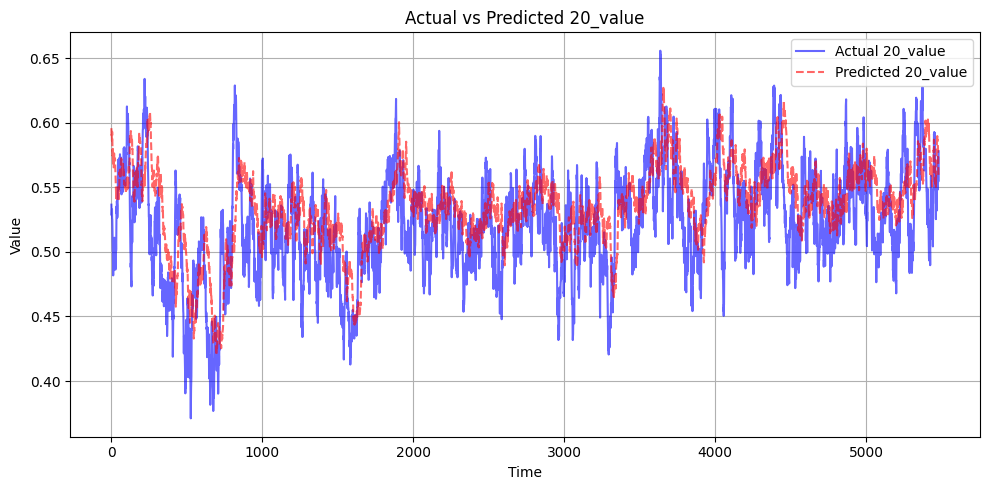

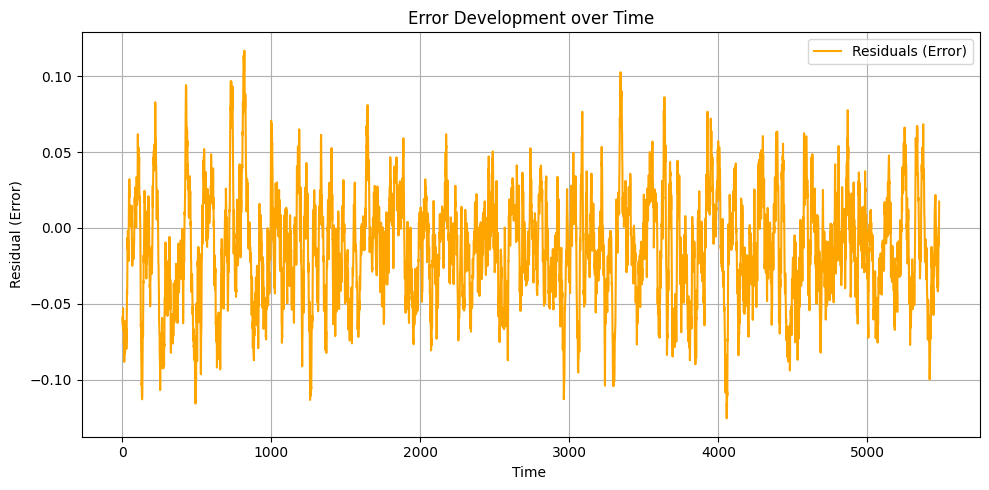

,Metric,Value
0,MSE,0.001474
1,MAE,0.030651
2,RMSE,0.038394
3,R2,0.120613
4,MAPE,6.029349
5,SMAPE,5.857377
6,SAE,168.028388


In [66]:
y_pred=lstm_20_model.predict(X_test_20)
er.evaluate_n_values(y_test_20,y_pred.squeeze(axis=-1), 20)